<a href="https://colab.research.google.com/github/yamadakudasai/STUDY_FOG_VO_ISiT_Turin_K_D/blob/main/PIT_labs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Лабараторная работа 2
---



=== Метрики (RU) ===
Конвейер: Датчик → Fog → Курьер → Телефон
Средняя сквозная задержка (мс): 86.13
~95-й перцентиль задержки (мс): 118.95


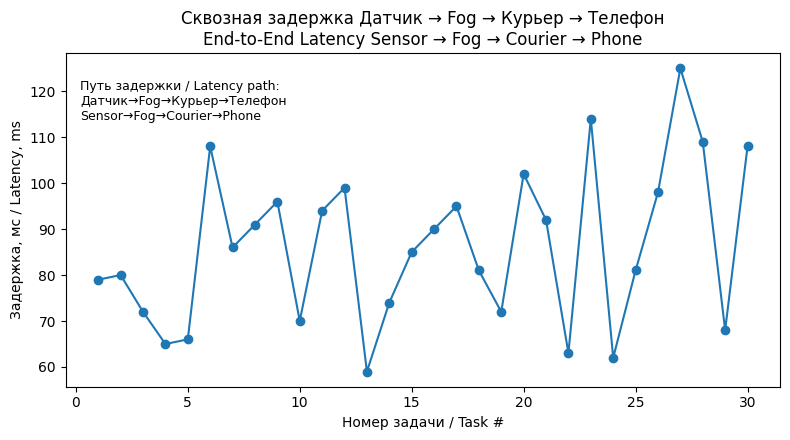

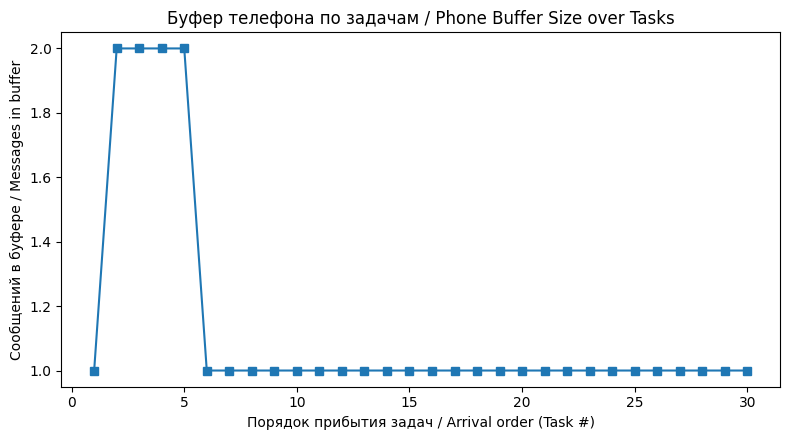

In [ ]:
"""
viz_phone_pipeline_bilingual.py

Билингвальная визуализация конвейера: Датчик → Fog → Курьер → Телефон.
Bilingual visualization of the pipeline: Sensor → Fog → Courier → Phone.

Показываем / We show:
  • Сквозная задержка "от датчика до телефона" для каждой задачи.
    End‑to‑end latency "sensor → phone" per task.
  • Размер буфера телефона по мере прибытия сообщений.
    Phone buffer size as messages arrive.
  • В консоли печатаются метрики на русском и английском.
    Console prints metrics in Russian and English.
"""
import random, statistics
import matplotlib.pyplot as plt

PIPELINE_RU = "Датчик → Fog → Курьер → Телефон"
PIPELINE_EN = "Sensor → Fog → Courier → Phone"

def simulate(n_tasks=30, seed=7):
    random.seed(seed)
    # Processing times (ms) per stage / Времена обработки (мс) на каждом этапе:
    sensor  = [random.randint(20, 60) for _ in range(n_tasks)]   # Sensor / Датчик
    fog     = [random.randint(10, 40) for _ in range(n_tasks)]   # Fog node / Fog‑узел
    courier = [random.randint(10, 40) for _ in range(n_tasks)]   # Courier / Курьер

    # End‑to‑end latency per task is the sum of stage times:
    # Сквозная задержка на задачу — это сумма времен этапов:
    latencies = [s + f + c for s, f, c in zip(sensor, fog, courier)]

    # Phone buffer: phone "reads" messages every read_interval_ms
    # Буфер телефона: телефон "читает" сообщения каждые read_interval_ms
    read_interval_ms = 200
    time = 0
    buffer_sizes = []
    buf = 0
    for L in latencies:
        time += L
        reads = time // read_interval_ms
        for _ in range(int(reads)):
            if buf > 0:
                buf -= 1
        buf += 1
        buffer_sizes.append(buf)

    avg_latency = statistics.mean(latencies)
    p95 = statistics.quantiles(latencies, n=20)[18]  # ≈95th percentile

    return latencies, buffer_sizes, avg_latency, p95

def plot(latencies, buffer_sizes):
    # Plot 1: end‑to‑end latency (RU/EN)
    plt.figure(figsize=(8, 4.5))
    x = range(1, len(latencies)+1)
    plt.plot(x, latencies, marker='o')
    plt.title(f"Сквозная задержка {PIPELINE_RU}\nEnd-to-End Latency {PIPELINE_EN}")
    plt.xlabel("Номер задачи / Task #")
    plt.ylabel("Задержка, мс / Latency, ms")
    # Пояснение прямо на графике:
    plt.text(0.02, 0.92,
             "Путь задержки / Latency path:\nДатчик→Fog→Курьер→Телефон\nSensor→Fog→Courier→Phone",
             transform=plt.gca().transAxes, fontsize=9, va='top')
    plt.tight_layout()
    plt.show()

    # Plot 2: phone buffer over arrivals (RU/EN)
    plt.figure(figsize=(8, 4.5))
    plt.plot(range(1, len(buffer_sizes)+1), buffer_sizes, marker='s')
    plt.title("Буфер телефона по задачам / Phone Buffer Size over Tasks")
    plt.xlabel("Порядок прибытия задач / Arrival order (Task #)")
    plt.ylabel("Сообщений в буфере / Messages in buffer")
    plt.tight_layout()
    plt.show()

def main():
    latencies, buffer_sizes, avg_latency, p95 = simulate()

    # Console output in RU and EN
    print("=== Метрики (RU) ===")
    print(f"Конвейер: {PIPELINE_RU}")
    print(f"Средняя сквозная задержка (мс): {avg_latency:.2f}")
    print(f"~95-й перцентиль задержки (мс): {p95:.2f}")

    # print("\n=== Metrics (EN) ===")
    # print(f"Pipeline: {PIPELINE_EN}")
    # print(f"Average end-to-end latency (ms): {avg_latency:.2f}")
    # print(f"~95th percentile latency (ms): {p95:.2f}")

    plot(latencies, buffer_sizes)

if __name__ == '__main__':
    main()


# Лабараторная работа 3

Эталонная модель

🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО
🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD
----------------------------------------------------------------------
⚙️  Загружена конфигурация:
   Краевые устройства: 10000
   Fog-узлы: 10000
   Облачные серверы: 100
   Задачи: 200
МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS

КОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:
  Краевые устройства: 10000
  Fog-узлы: 10000
  Облачные серверы: 100
  Всего задач: 200

ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:
  Средняя сквозная задержка: 134.88 мс
  95-й перцентиль задержки: 171.00 мс
  99-й перцентиль задержки: 188.90 мс
  Стандартное отклонение: 20.57 мс
  Минимальная задержка: 89.00 мс
  Максимальная задержка: 192.00 мс

РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:
  Краевой уровень (Edge): 12.53 мс (9.3%)
  Туманный уровень (Fog): 55.05 мс (40.8%)
  Облачный уровень (Cloud): 20.86 мс (15.5%)
  Сетевые задержки: 46.45 мс (34.4%)

СТАЦИОНАРНЫЕ УСТРОЙ

/tmp/ipython-input-1264287045.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


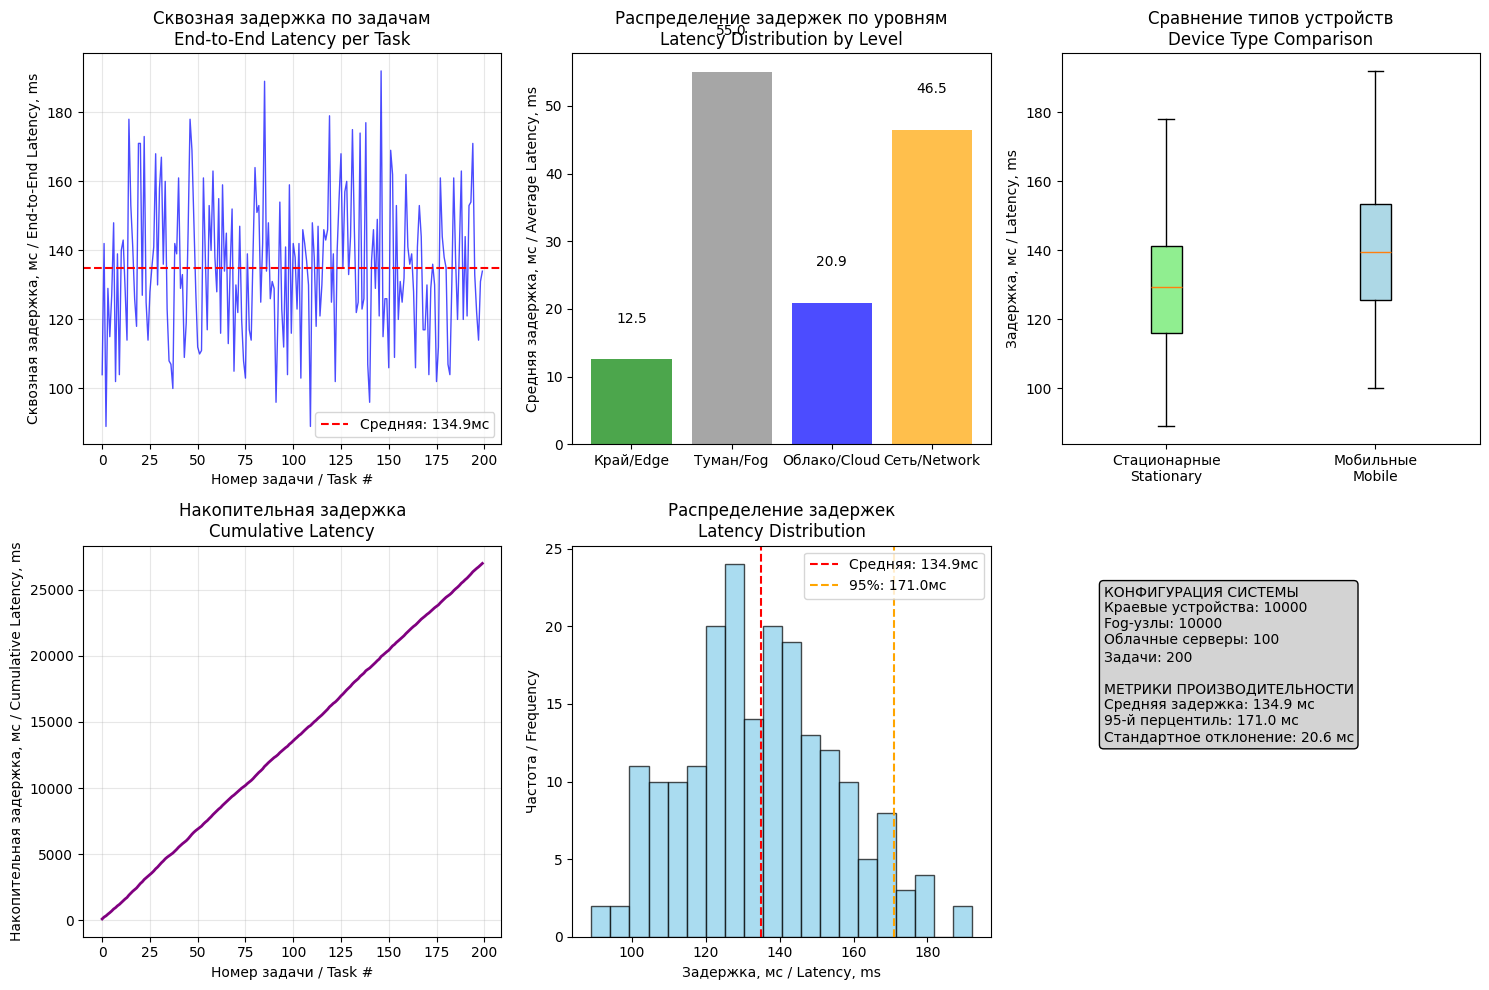


✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!
📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()


In [ ]:
"""
viz_cloud_fog_edge_pipeline_custom.py

Визуализация конвейера для эталонной архитектуры: Край → Туман → Облако
с возможностью настройки всех параметров системы

Показываем / We show:
  • Сквозная задержка "от краевого устройства до облака" для каждой задачи
  • Задержки на каждом уровне вычислений
  • Динамика очередей на Fog-узлах
  • Метрики производительности распределённой системы
"""
import random, statistics
import matplotlib.pyplot as plt
import numpy as np

class DistributedSystemSimulator:
    def __init__(self, n_edge_devices=100, n_fog_nodes=10, n_cloud_servers=3):
        self.n_edge_devices = n_edge_devices
        self.n_fog_nodes = n_fog_nodes
        self.n_cloud_servers = n_cloud_servers

        # Инициализация устройств
        self.edge_devices = self._init_edge_devices()
        self.fog_nodes = self._init_fog_nodes()
        self.cloud_servers = self._init_cloud_servers()

    def _init_edge_devices(self):
        """Инициализация краевых устройств (стационарные и мобильные)"""
        devices = []
        for i in range(self.n_edge_devices):
            device_type = "стационарный" if i % 2 == 0 else "мобильный"
            # Мобильные устройства имеют немного другие характеристики
            if device_type == "мобильный":
                processing_range = (8, 20)  # Немного выше задержка
                network_range = (8, 20)      # Менее стабильное соединение
            else:
                processing_range = (5, 15)  # Стабильная задержка
                network_range = (5, 15)      # Стабильное соединение

            devices.append({
                'id': f"Edge_{i}",
                'type': device_type,
                'processing_delay': random.randint(*processing_range),  # мс
                'network_delay': random.randint(*network_range),        # мс
                'assigned_fog': random.randint(0, self.n_fog_nodes-1)
            })
        return devices

    def _init_fog_nodes(self):
        """Инициализация Fog-узлов"""
        nodes = []
        for i in range(self.n_fog_nodes):
            # Разные Fog-узлы могут иметь разную производительность
            capacity_factor = random.uniform(0.8, 1.2)
            nodes.append({
                'id': f"Fog_{i}",
                'processing_delay_range': (int(30 * capacity_factor), int(80 * capacity_factor)),
                'queue_capacity': 400,
                'current_queue': 0,
                'assigned_cloud': random.randint(0, self.n_cloud_servers-1),
                'processed_tasks': 0
            })
        return nodes

    def _init_cloud_servers(self):
        """Инициализация облачных серверов"""
        servers = []
        for i in range(self.n_cloud_servers):
            # Облачные серверы обычно более производительные
            servers.append({
                'id': f"Cloud_{i}",
                'processing_delay_range': (10, 30),  # мс
                'storage_capacity': 1000,
                'processed_tasks': 0
            })
        return servers

def simulate_ethernet_architecture_custom(n_tasks=100, simulator=None, seed=42):
    """
    Симуляция эталонной архитектуры с кастомным симулятором
    """
    if simulator is None:
        simulator = DistributedSystemSimulator()

    random.seed(seed)
    tasks = []

    for task_id in range(n_tasks):
        # Случайное краевое устройство генерирует задачу
        edge_device = random.choice(simulator.edge_devices)
        fog_node = simulator.fog_nodes[edge_device['assigned_fog']]
        cloud_server = simulator.cloud_servers[fog_node['assigned_cloud']]

        # Задержки на каждом этапе
        edge_processing = edge_device['processing_delay']
        edge_to_fog_network = edge_device['network_delay']

        fog_processing = random.randint(*fog_node['processing_delay_range'])
        fog_queue_delay = fog_node['current_queue'] * 2  # 2 мс на задачу в очереди

        fog_to_cloud_network = random.randint(20, 50)  # Более высокая задержка до облака
        cloud_processing = random.randint(*cloud_server['processing_delay_range'])

        # Обновление очереди Fog-узла
        if fog_node['current_queue'] < fog_node['queue_capacity']:
            fog_node['current_queue'] += 1
        else:
            fog_queue_delay += 10  # Штраф за переполнение очереди

        # Общая сквозная задержка
        end_to_end_latency = (edge_processing + edge_to_fog_network +
                             fog_processing + fog_queue_delay +
                             fog_to_cloud_network + cloud_processing)

        tasks.append({
            'task_id': task_id,
            'edge_device': edge_device['id'],
            'edge_type': edge_device['type'],
            'fog_node': fog_node['id'],
            'cloud_server': cloud_server['id'],
            'edge_processing': edge_processing,
            'edge_to_fog_network': edge_to_fog_network,
            'fog_processing': fog_processing,
            'fog_queue_delay': fog_queue_delay,
            'fog_to_cloud_network': fog_to_cloud_network,
            'cloud_processing': cloud_processing,
            'end_to_end_latency': end_to_end_latency
        })

        # Уменьшение очереди Fog-узла (обработка задач)
        if random.random() < 0.3:  # 30% chance to process a task from queue
            if fog_node['current_queue'] > 0:
                fog_node['current_queue'] -= 1
                fog_node['processed_tasks'] += 1

        # Обновление статистики облачного сервера
        cloud_server['processed_tasks'] += 1

    return tasks

def analyze_performance(tasks):
    """Анализ производительности системы"""
    latencies = [task['end_to_end_latency'] for task in tasks]
    edge_latencies = [task['edge_processing'] for task in tasks]
    fog_latencies = [task['fog_processing'] + task['fog_queue_delay'] for task in tasks]
    cloud_latencies = [task['cloud_processing'] for task in tasks]
    network_latencies = [task['edge_to_fog_network'] + task['fog_to_cloud_network'] for task in tasks]

    # Статистика
    stats = {
        'avg_end_to_end': statistics.mean(latencies),
        'p95_end_to_end': statistics.quantiles(latencies, n=20)[18],
        'p99_end_to_end': statistics.quantiles(latencies, n=100)[98],
        'avg_edge': statistics.mean(edge_latencies),
        'avg_fog': statistics.mean(fog_latencies),
        'avg_cloud': statistics.mean(cloud_latencies),
        'avg_network': statistics.mean(network_latencies),
        'max_latency': max(latencies),
        'min_latency': min(latencies),
        'std_latency': statistics.stdev(latencies) if len(latencies) > 1 else 0
    }

    return stats

def plot_comprehensive_results(tasks, stats, config):
    """Построение комплексных графиков результатов"""

    plt.figure(figsize=(15, 10))

    # График 1: Сквозная задержка по задачам
    plt.subplot(2, 3, 1)
    task_ids = [task['task_id'] for task in tasks]
    latencies = [task['end_to_end_latency'] for task in tasks]
    plt.plot(task_ids, latencies, 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=stats['avg_end_to_end'], color='r', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Сквозная задержка, мс / End-to-End Latency, ms')
    plt.title('Сквозная задержка по задачам\nEnd-to-End Latency per Task')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 2: Распределение задержек по уровням
    plt.subplot(2, 3, 2)
    components = ['Край/Edge', 'Туман/Fog', 'Облако/Cloud', 'Сеть/Network']
    avg_latencies = [stats['avg_edge'], stats['avg_fog'], stats['avg_cloud'], stats['avg_network']]
    colors = ['green', 'gray', 'blue', 'orange']
    bars = plt.bar(components, avg_latencies, color=colors, alpha=0.7)
    plt.ylabel('Средняя задержка, мс / Average Latency, ms')
    plt.title('Распределение задержек по уровням\nLatency Distribution by Level')

    # Добавление значений на столбцы
    for bar, value in zip(bars, avg_latencies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom')

    # График 3: Сравнение стационарных и мобильных устройств
    plt.subplot(2, 3, 3)
    stationary_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'стационарный']
    mobile_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'мобильный']

    box_data = [stationary_latencies, mobile_latencies]
    box_labels = ['Стационарные\nStationary', 'Мобильные\nMobile']
    box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

    # Цвета для boxplot
    colors = ['lightgreen', 'lightblue']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel('Задержка, мс / Latency, ms')
    plt.title('Сравнение типов устройств\nDevice Type Comparison')

    # График 4: Накопительная задержка
    plt.subplot(2, 3, 4)
    cumulative_latency = np.cumsum([task['end_to_end_latency'] for task in tasks])
    plt.plot(task_ids, cumulative_latency, 'purple', linewidth=2)
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Накопительная задержка, мс / Cumulative Latency, ms')
    plt.title('Накопительная задержка\nCumulative Latency')
    plt.grid(True, alpha=0.3)

    # График 5: Гистограмма распределения задержек
    plt.subplot(2, 3, 5)
    plt.hist(latencies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(stats['avg_end_to_end'], color='red', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.axvline(stats['p95_end_to_end'], color='orange', linestyle='--', label=f'95%: {stats["p95_end_to_end"]:.1f}мс')
    plt.xlabel('Задержка, мс / Latency, ms')
    plt.ylabel('Частота / Frequency')
    plt.title('Распределение задержек\nLatency Distribution')
    plt.legend()

    # График 6: Информация о конфигурации
    plt.subplot(2, 3, 6)
    plt.axis('off')
    config_text = (
        f"КОНФИГУРАЦИЯ СИСТЕМЫ\n"
        f"Краевые устройства: {config['edge_devices']}\n"
        f"Fog-узлы: {config['fog_nodes']}\n"
        f"Облачные серверы: {config['cloud_servers']}\n"
        f"Задачи: {config['tasks']}\n\n"
        f"МЕТРИКИ ПРОИЗВОДИТЕЛЬНОСТИ\n"
        f"Средняя задержка: {stats['avg_end_to_end']:.1f} мс\n"
        f"95-й перцентиль: {stats['p95_end_to_end']:.1f} мс\n"
        f"Стандартное отклонение: {stats['std_latency']:.1f} мс"
    )
    plt.text(0.1, 0.9, config_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

def print_detailed_metrics(tasks, stats, config):
    """Вывод детализированных метрик"""
    print("=" * 70)
    print("МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS")
    print("=" * 70)

    print(f"\nКОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:")
    print(f"  Краевые устройства: {config['edge_devices']}")
    print(f"  Fog-узлы: {config['fog_nodes']}")
    print(f"  Облачные серверы: {config['cloud_servers']}")
    print(f"  Всего задач: {config['tasks']}")

    print(f"\nОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:")
    print(f"  Средняя сквозная задержка: {stats['avg_end_to_end']:.2f} мс")
    print(f"  95-й перцентиль задержки: {stats['p95_end_to_end']:.2f} мс")
    print(f"  99-й перцентиль задержки: {stats['p99_end_to_end']:.2f} мс")
    print(f"  Стандартное отклонение: {stats['std_latency']:.2f} мс")
    print(f"  Минимальная задержка: {stats['min_latency']:.2f} мс")
    print(f"  Максимальная задержка: {stats['max_latency']:.2f} мс")

    print(f"\nРАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:")
    print(f"  Краевой уровень (Edge): {stats['avg_edge']:.2f} мс ({stats['avg_edge']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Туманный уровень (Fog): {stats['avg_fog']:.2f} мс ({stats['avg_fog']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Облачный уровень (Cloud): {stats['avg_cloud']:.2f} мс ({stats['avg_cloud']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Сетевые задержки: {stats['avg_network']:.2f} мс ({stats['avg_network']/stats['avg_end_to_end']*100:.1f}%)")

    # Анализ по типам устройств
    stationary_tasks = [t for t in tasks if t['edge_type'] == 'стационарный']
    mobile_tasks = [t for t in tasks if t['edge_type'] == 'мобильный']

    if stationary_tasks:
        avg_stationary = statistics.mean([t['end_to_end_latency'] for t in stationary_tasks])
        print(f"\nСТАЦИОНАРНЫЕ УСТРОЙСТВА / STATIONARY DEVICES:")
        print(f"  Количество задач: {len(stationary_tasks)} ({len(stationary_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_stationary:.2f} мс")

    if mobile_tasks:
        avg_mobile = statistics.mean([t['end_to_end_latency'] for t in mobile_tasks])
        print(f"\nМОБИЛЬНЫЕ УСТРОЙСТВА / MOBILE DEVICES:")
        print(f"  Количество задач: {len(mobile_tasks)} ({len(mobile_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_mobile:.2f} мс")

def simulate_custom_config():
    """Функция для быстрой настройки конфигурации системы"""

    # 🎛️ НАСТРОЙКА ПАРАМЕТРОВ СИСТЕМЫ - МЕНЯЙТЕ ЭТИ ЧИСЛА 🎛️
    CONFIG = {
        'edge_devices': 10000,      # ↦ Количество краевых устройств (100-10000)
        'fog_nodes': 10000,          # ↦ Количество Fog-узлов (100-10000)
        'cloud_servers': 100,       # ↦ Количество облачных серверов (1-100)
        'tasks': 200,             # ↦ Количество задач для симуляции
        'seed': 42               # ↦ Seed для воспроизводимости результатов
    }

    print(f"⚙️  Загружена конфигурация:")
    print(f"   Краевые устройства: {CONFIG['edge_devices']}")
    print(f"   Fog-узлы: {CONFIG['fog_nodes']}")
    print(f"   Облачные серверы: {CONFIG['cloud_servers']}")
    print(f"   Задачи: {CONFIG['tasks']}")

    # Проверка корректности конфигурации
    if CONFIG['edge_devices'] < CONFIG['fog_nodes']:
        print("⚠️  Предупреждение: Fog-узлов больше чем краевых устройств")

    if CONFIG['fog_nodes'] < CONFIG['cloud_servers']:
        print("⚠️  Предупреждение: Облачных серверов больше чем Fog-узлов")

    # Инициализация симулятора
    simulator = DistributedSystemSimulator(
        n_edge_devices=CONFIG['edge_devices'],
        n_fog_nodes=CONFIG['fog_nodes'],
        n_cloud_servers=CONFIG['cloud_servers']
    )

    # Запуск симуляции
    tasks = simulate_ethernet_architecture_custom(
        n_tasks=CONFIG['tasks'],
        simulator=simulator,
        seed=CONFIG['seed']
    )

    return tasks, simulator, CONFIG

def main():
    """Основная функция с настраиваемыми параметрами"""

    print("🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО")
    print("🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD")
    print("-" * 70)

    # Запуск симуляции с кастомной конфигурацией
    tasks, simulator, config = simulate_custom_config()

    # Анализ производительности
    stats = analyze_performance(tasks)

    # Вывод результатов
    print_detailed_metrics(tasks, stats, config)

    # Построение графиков
    plot_comprehensive_results(tasks, stats, config)

    print(f"\n✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
    print(f"📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()")

if __name__ == '__main__':
    main()

Малый масштаб

🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО
🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD
----------------------------------------------------------------------
⚙️  Загружена конфигурация:
   Краевые устройства: 100
   Fog-узлы: 10
   Облачные серверы: 3
   Задачи: 200
МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS

КОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:
  Краевые устройства: 100
  Fog-узлы: 10
  Облачные серверы: 3
  Всего задач: 200

ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:
  Средняя сквозная задержка: 152.56 мс
  95-й перцентиль задержки: 188.95 мс
  99-й перцентиль задержки: 206.96 мс
  Стандартное отклонение: 22.79 мс
  Минимальная задержка: 93.00 мс
  Максимальная задержка: 213.00 мс

РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:
  Краевой уровень (Edge): 12.38 мс (8.1%)
  Туманный уровень (Fog): 72.96 мс (47.8%)
  Облачный уровень (Cloud): 19.74 мс (12.9%)
  Сетевые задержки: 47.48 мс (31.1%)

СТАЦИОНАРНЫЕ УСТРОЙСТВА / STATION

/tmp/ipython-input-3316641318.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


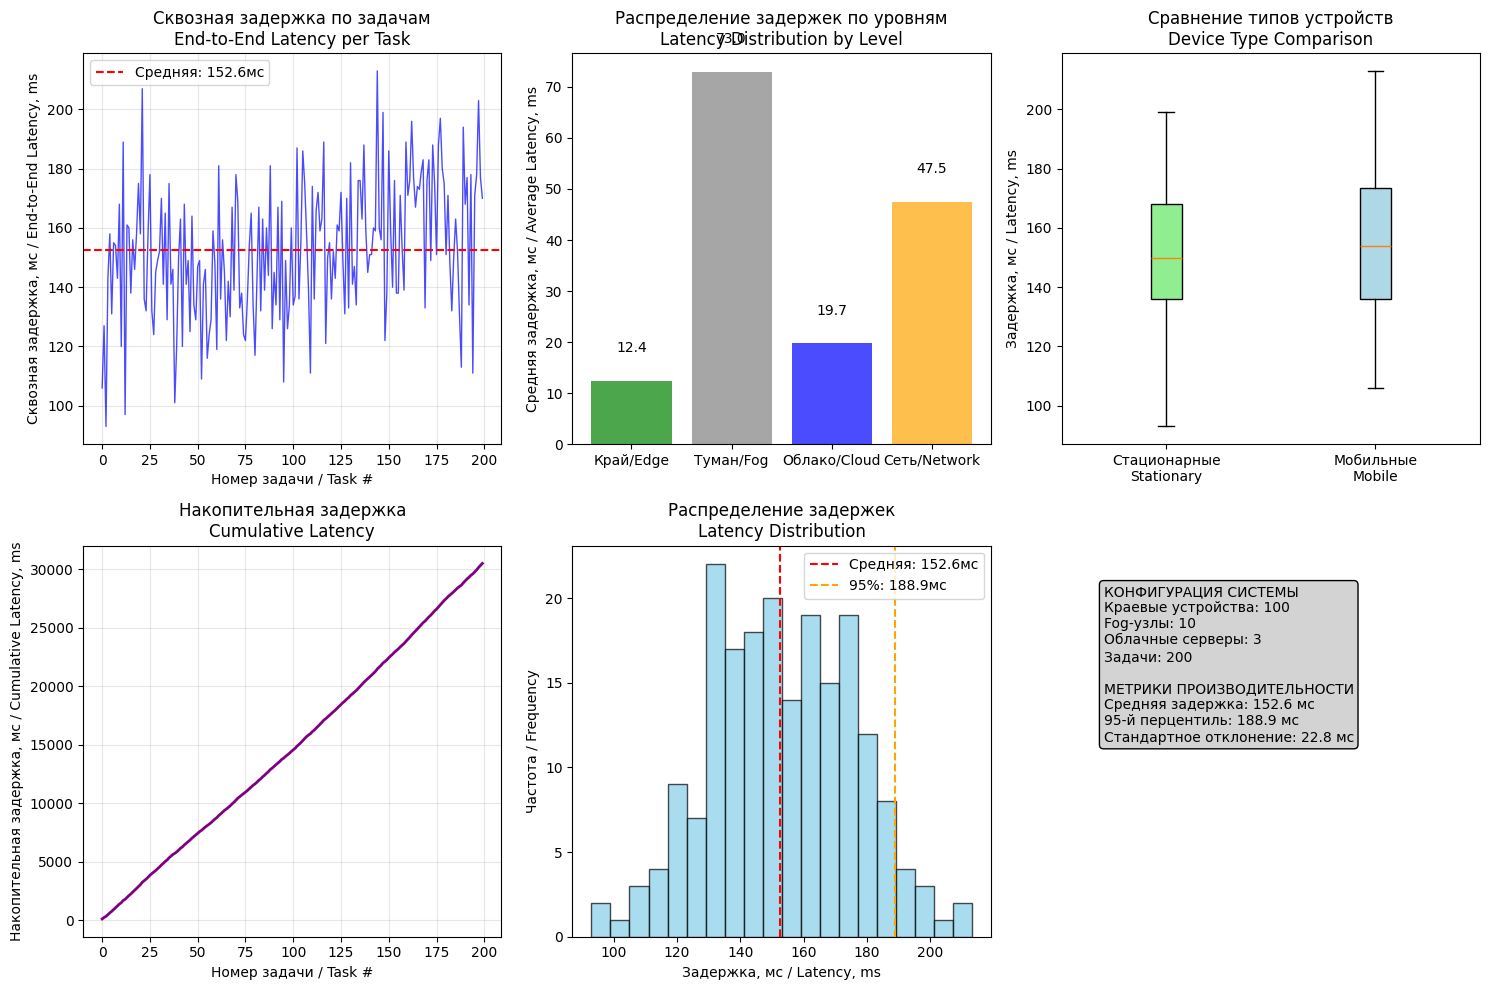


✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!
📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()


In [ ]:
"""
viz_cloud_fog_edge_pipeline_custom.py

Визуализация конвейера для эталонной архитектуры: Край → Туман → Облако
с возможностью настройки всех параметров системы

Показываем / We show:
  • Сквозная задержка "от краевого устройства до облака" для каждой задачи
  • Задержки на каждом уровне вычислений
  • Динамика очередей на Fog-узлах
  • Метрики производительности распределённой системы
"""
import random, statistics
import matplotlib.pyplot as plt
import numpy as np

class DistributedSystemSimulator:
    def __init__(self, n_edge_devices=100, n_fog_nodes=10, n_cloud_servers=3):
        self.n_edge_devices = n_edge_devices
        self.n_fog_nodes = n_fog_nodes
        self.n_cloud_servers = n_cloud_servers

        # Инициализация устройств
        self.edge_devices = self._init_edge_devices()
        self.fog_nodes = self._init_fog_nodes()
        self.cloud_servers = self._init_cloud_servers()

    def _init_edge_devices(self):
        """Инициализация краевых устройств (стационарные и мобильные)"""
        devices = []
        for i in range(self.n_edge_devices):
            device_type = "стационарный" if i % 2 == 0 else "мобильный"
            # Мобильные устройства имеют немного другие характеристики
            if device_type == "мобильный":
                processing_range = (8, 20)  # Немного выше задержка
                network_range = (8, 20)      # Менее стабильное соединение
            else:
                processing_range = (5, 15)  # Стабильная задержка
                network_range = (5, 15)      # Стабильное соединение

            devices.append({
                'id': f"Edge_{i}",
                'type': device_type,
                'processing_delay': random.randint(*processing_range),  # мс
                'network_delay': random.randint(*network_range),        # мс
                'assigned_fog': random.randint(0, self.n_fog_nodes-1)
            })
        return devices

    def _init_fog_nodes(self):
        """Инициализация Fog-узлов"""
        nodes = []
        for i in range(self.n_fog_nodes):
            # Разные Fog-узлы могут иметь разную производительность
            capacity_factor = random.uniform(0.8, 1.2)
            nodes.append({
                'id': f"Fog_{i}",
                'processing_delay_range': (int(30 * capacity_factor), int(80 * capacity_factor)),
                'queue_capacity': 400,
                'current_queue': 0,
                'assigned_cloud': random.randint(0, self.n_cloud_servers-1),
                'processed_tasks': 0
            })
        return nodes

    def _init_cloud_servers(self):
        """Инициализация облачных серверов"""
        servers = []
        for i in range(self.n_cloud_servers):
            # Облачные серверы обычно более производительные
            servers.append({
                'id': f"Cloud_{i}",
                'processing_delay_range': (10, 30),  # мс
                'storage_capacity': 1000,
                'processed_tasks': 0
            })
        return servers

def simulate_ethernet_architecture_custom(n_tasks=100, simulator=None, seed=42):
    """
    Симуляция эталонной архитектуры с кастомным симулятором
    """
    if simulator is None:
        simulator = DistributedSystemSimulator()

    random.seed(seed)
    tasks = []

    for task_id in range(n_tasks):
        # Случайное краевое устройство генерирует задачу
        edge_device = random.choice(simulator.edge_devices)
        fog_node = simulator.fog_nodes[edge_device['assigned_fog']]
        cloud_server = simulator.cloud_servers[fog_node['assigned_cloud']]

        # Задержки на каждом этапе
        edge_processing = edge_device['processing_delay']
        edge_to_fog_network = edge_device['network_delay']

        fog_processing = random.randint(*fog_node['processing_delay_range'])
        fog_queue_delay = fog_node['current_queue'] * 2  # 2 мс на задачу в очереди

        fog_to_cloud_network = random.randint(20, 50)  # Более высокая задержка до облака
        cloud_processing = random.randint(*cloud_server['processing_delay_range'])

        # Обновление очереди Fog-узла
        if fog_node['current_queue'] < fog_node['queue_capacity']:
            fog_node['current_queue'] += 1
        else:
            fog_queue_delay += 10  # Штраф за переполнение очереди

        # Общая сквозная задержка
        end_to_end_latency = (edge_processing + edge_to_fog_network +
                             fog_processing + fog_queue_delay +
                             fog_to_cloud_network + cloud_processing)

        tasks.append({
            'task_id': task_id,
            'edge_device': edge_device['id'],
            'edge_type': edge_device['type'],
            'fog_node': fog_node['id'],
            'cloud_server': cloud_server['id'],
            'edge_processing': edge_processing,
            'edge_to_fog_network': edge_to_fog_network,
            'fog_processing': fog_processing,
            'fog_queue_delay': fog_queue_delay,
            'fog_to_cloud_network': fog_to_cloud_network,
            'cloud_processing': cloud_processing,
            'end_to_end_latency': end_to_end_latency
        })

        # Уменьшение очереди Fog-узла (обработка задач)
        if random.random() < 0.3:  # 30% chance to process a task from queue
            if fog_node['current_queue'] > 0:
                fog_node['current_queue'] -= 1
                fog_node['processed_tasks'] += 1

        # Обновление статистики облачного сервера
        cloud_server['processed_tasks'] += 1

    return tasks

def analyze_performance(tasks):
    """Анализ производительности системы"""
    latencies = [task['end_to_end_latency'] for task in tasks]
    edge_latencies = [task['edge_processing'] for task in tasks]
    fog_latencies = [task['fog_processing'] + task['fog_queue_delay'] for task in tasks]
    cloud_latencies = [task['cloud_processing'] for task in tasks]
    network_latencies = [task['edge_to_fog_network'] + task['fog_to_cloud_network'] for task in tasks]

    # Статистика
    stats = {
        'avg_end_to_end': statistics.mean(latencies),
        'p95_end_to_end': statistics.quantiles(latencies, n=20)[18],
        'p99_end_to_end': statistics.quantiles(latencies, n=100)[98],
        'avg_edge': statistics.mean(edge_latencies),
        'avg_fog': statistics.mean(fog_latencies),
        'avg_cloud': statistics.mean(cloud_latencies),
        'avg_network': statistics.mean(network_latencies),
        'max_latency': max(latencies),
        'min_latency': min(latencies),
        'std_latency': statistics.stdev(latencies) if len(latencies) > 1 else 0
    }

    return stats

def plot_comprehensive_results(tasks, stats, config):
    """Построение комплексных графиков результатов"""

    plt.figure(figsize=(15, 10))

    # График 1: Сквозная задержка по задачам
    plt.subplot(2, 3, 1)
    task_ids = [task['task_id'] for task in tasks]
    latencies = [task['end_to_end_latency'] for task in tasks]
    plt.plot(task_ids, latencies, 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=stats['avg_end_to_end'], color='r', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Сквозная задержка, мс / End-to-End Latency, ms')
    plt.title('Сквозная задержка по задачам\nEnd-to-End Latency per Task')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 2: Распределение задержек по уровням
    plt.subplot(2, 3, 2)
    components = ['Край/Edge', 'Туман/Fog', 'Облако/Cloud', 'Сеть/Network']
    avg_latencies = [stats['avg_edge'], stats['avg_fog'], stats['avg_cloud'], stats['avg_network']]
    colors = ['green', 'gray', 'blue', 'orange']
    bars = plt.bar(components, avg_latencies, color=colors, alpha=0.7)
    plt.ylabel('Средняя задержка, мс / Average Latency, ms')
    plt.title('Распределение задержек по уровням\nLatency Distribution by Level')

    # Добавление значений на столбцы
    for bar, value in zip(bars, avg_latencies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom')

    # График 3: Сравнение стационарных и мобильных устройств
    plt.subplot(2, 3, 3)
    stationary_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'стационарный']
    mobile_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'мобильный']

    box_data = [stationary_latencies, mobile_latencies]
    box_labels = ['Стационарные\nStationary', 'Мобильные\nMobile']
    box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

    # Цвета для boxplot
    colors = ['lightgreen', 'lightblue']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel('Задержка, мс / Latency, ms')
    plt.title('Сравнение типов устройств\nDevice Type Comparison')

    # График 4: Накопительная задержка
    plt.subplot(2, 3, 4)
    cumulative_latency = np.cumsum([task['end_to_end_latency'] for task in tasks])
    plt.plot(task_ids, cumulative_latency, 'purple', linewidth=2)
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Накопительная задержка, мс / Cumulative Latency, ms')
    plt.title('Накопительная задержка\nCumulative Latency')
    plt.grid(True, alpha=0.3)

    # График 5: Гистограмма распределения задержек
    plt.subplot(2, 3, 5)
    plt.hist(latencies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(stats['avg_end_to_end'], color='red', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.axvline(stats['p95_end_to_end'], color='orange', linestyle='--', label=f'95%: {stats["p95_end_to_end"]:.1f}мс')
    plt.xlabel('Задержка, мс / Latency, ms')
    plt.ylabel('Частота / Frequency')
    plt.title('Распределение задержек\nLatency Distribution')
    plt.legend()

    # График 6: Информация о конфигурации
    plt.subplot(2, 3, 6)
    plt.axis('off')
    config_text = (
        f"КОНФИГУРАЦИЯ СИСТЕМЫ\n"
        f"Краевые устройства: {config['edge_devices']}\n"
        f"Fog-узлы: {config['fog_nodes']}\n"
        f"Облачные серверы: {config['cloud_servers']}\n"
        f"Задачи: {config['tasks']}\n\n"
        f"МЕТРИКИ ПРОИЗВОДИТЕЛЬНОСТИ\n"
        f"Средняя задержка: {stats['avg_end_to_end']:.1f} мс\n"
        f"95-й перцентиль: {stats['p95_end_to_end']:.1f} мс\n"
        f"Стандартное отклонение: {stats['std_latency']:.1f} мс"
    )
    plt.text(0.1, 0.9, config_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

def print_detailed_metrics(tasks, stats, config):
    """Вывод детализированных метрик"""
    print("=" * 70)
    print("МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS")
    print("=" * 70)

    print(f"\nКОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:")
    print(f"  Краевые устройства: {config['edge_devices']}")
    print(f"  Fog-узлы: {config['fog_nodes']}")
    print(f"  Облачные серверы: {config['cloud_servers']}")
    print(f"  Всего задач: {config['tasks']}")

    print(f"\nОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:")
    print(f"  Средняя сквозная задержка: {stats['avg_end_to_end']:.2f} мс")
    print(f"  95-й перцентиль задержки: {stats['p95_end_to_end']:.2f} мс")
    print(f"  99-й перцентиль задержки: {stats['p99_end_to_end']:.2f} мс")
    print(f"  Стандартное отклонение: {stats['std_latency']:.2f} мс")
    print(f"  Минимальная задержка: {stats['min_latency']:.2f} мс")
    print(f"  Максимальная задержка: {stats['max_latency']:.2f} мс")

    print(f"\nРАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:")
    print(f"  Краевой уровень (Edge): {stats['avg_edge']:.2f} мс ({stats['avg_edge']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Туманный уровень (Fog): {stats['avg_fog']:.2f} мс ({stats['avg_fog']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Облачный уровень (Cloud): {stats['avg_cloud']:.2f} мс ({stats['avg_cloud']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Сетевые задержки: {stats['avg_network']:.2f} мс ({stats['avg_network']/stats['avg_end_to_end']*100:.1f}%)")

    # Анализ по типам устройств
    stationary_tasks = [t for t in tasks if t['edge_type'] == 'стационарный']
    mobile_tasks = [t for t in tasks if t['edge_type'] == 'мобильный']

    if stationary_tasks:
        avg_stationary = statistics.mean([t['end_to_end_latency'] for t in stationary_tasks])
        print(f"\nСТАЦИОНАРНЫЕ УСТРОЙСТВА / STATIONARY DEVICES:")
        print(f"  Количество задач: {len(stationary_tasks)} ({len(stationary_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_stationary:.2f} мс")

    if mobile_tasks:
        avg_mobile = statistics.mean([t['end_to_end_latency'] for t in mobile_tasks])
        print(f"\nМОБИЛЬНЫЕ УСТРОЙСТВА / MOBILE DEVICES:")
        print(f"  Количество задач: {len(mobile_tasks)} ({len(mobile_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_mobile:.2f} мс")

def simulate_custom_config():
    """Функция для быстрой настройки конфигурации системы"""

    # 🎛️ НАСТРОЙКА ПАРАМЕТРОВ СИСТЕМЫ - МЕНЯЙТЕ ЭТИ ЧИСЛА 🎛️
    CONFIG = {
        'edge_devices': 100,      # ↦ Количество краевых устройств (100-10000)
        'fog_nodes': 10,          # ↦ Количество Fog-узлов (100-10000)
        'cloud_servers': 3,       # ↦ Количество облачных серверов (1-100)
        'tasks': 200,             # ↦ Количество задач для симуляции
        'seed': 42               # ↦ Seed для воспроизводимости результатов
    }

    print(f"⚙️  Загружена конфигурация:")
    print(f"   Краевые устройства: {CONFIG['edge_devices']}")
    print(f"   Fog-узлы: {CONFIG['fog_nodes']}")
    print(f"   Облачные серверы: {CONFIG['cloud_servers']}")
    print(f"   Задачи: {CONFIG['tasks']}")

    # Проверка корректности конфигурации
    if CONFIG['edge_devices'] < CONFIG['fog_nodes']:
        print("⚠️  Предупреждение: Fog-узлов больше чем краевых устройств")

    if CONFIG['fog_nodes'] < CONFIG['cloud_servers']:
        print("⚠️  Предупреждение: Облачных серверов больше чем Fog-узлов")

    # Инициализация симулятора
    simulator = DistributedSystemSimulator(
        n_edge_devices=CONFIG['edge_devices'],
        n_fog_nodes=CONFIG['fog_nodes'],
        n_cloud_servers=CONFIG['cloud_servers']
    )

    # Запуск симуляции
    tasks = simulate_ethernet_architecture_custom(
        n_tasks=CONFIG['tasks'],
        simulator=simulator,
        seed=CONFIG['seed']
    )

    return tasks, simulator, CONFIG

def main():
    """Основная функция с настраиваемыми параметрами"""

    print("🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО")
    print("🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD")
    print("-" * 70)

    # Запуск симуляции с кастомной конфигурацией
    tasks, simulator, config = simulate_custom_config()

    # Анализ производительности
    stats = analyze_performance(tasks)

    # Вывод результатов
    print_detailed_metrics(tasks, stats, config)

    # Построение графиков
    plot_comprehensive_results(tasks, stats, config)

    print(f"\n✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
    print(f"📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()")

if __name__ == '__main__':
    main()

Средний масштаб

🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО
🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD
----------------------------------------------------------------------
⚙️  Загружена конфигурация:
   Краевые устройства: 500
   Fog-узлы: 50
   Облачные серверы: 10
   Задачи: 200
МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS

КОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:
  Краевые устройства: 500
  Fog-узлы: 50
  Облачные серверы: 10
  Всего задач: 200

ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:
  Средняя сквозная задержка: 137.43 мс
  95-й перцентиль задержки: 173.95 мс
  99-й перцентиль задержки: 184.97 мс
  Стандартное отклонение: 21.12 мс
  Минимальная задержка: 82.00 мс
  Максимальная задержка: 190.00 мс

РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:
  Краевой уровень (Edge): 11.70 мс (8.5%)
  Туманный уровень (Fog): 58.04 мс (42.2%)
  Облачный уровень (Cloud): 20.18 мс (14.7%)
  Сетевые задержки: 47.52 мс (34.6%)

СТАЦИОНАРНЫЕ УСТРОЙСТВА / STATI

/tmp/ipython-input-2478929409.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


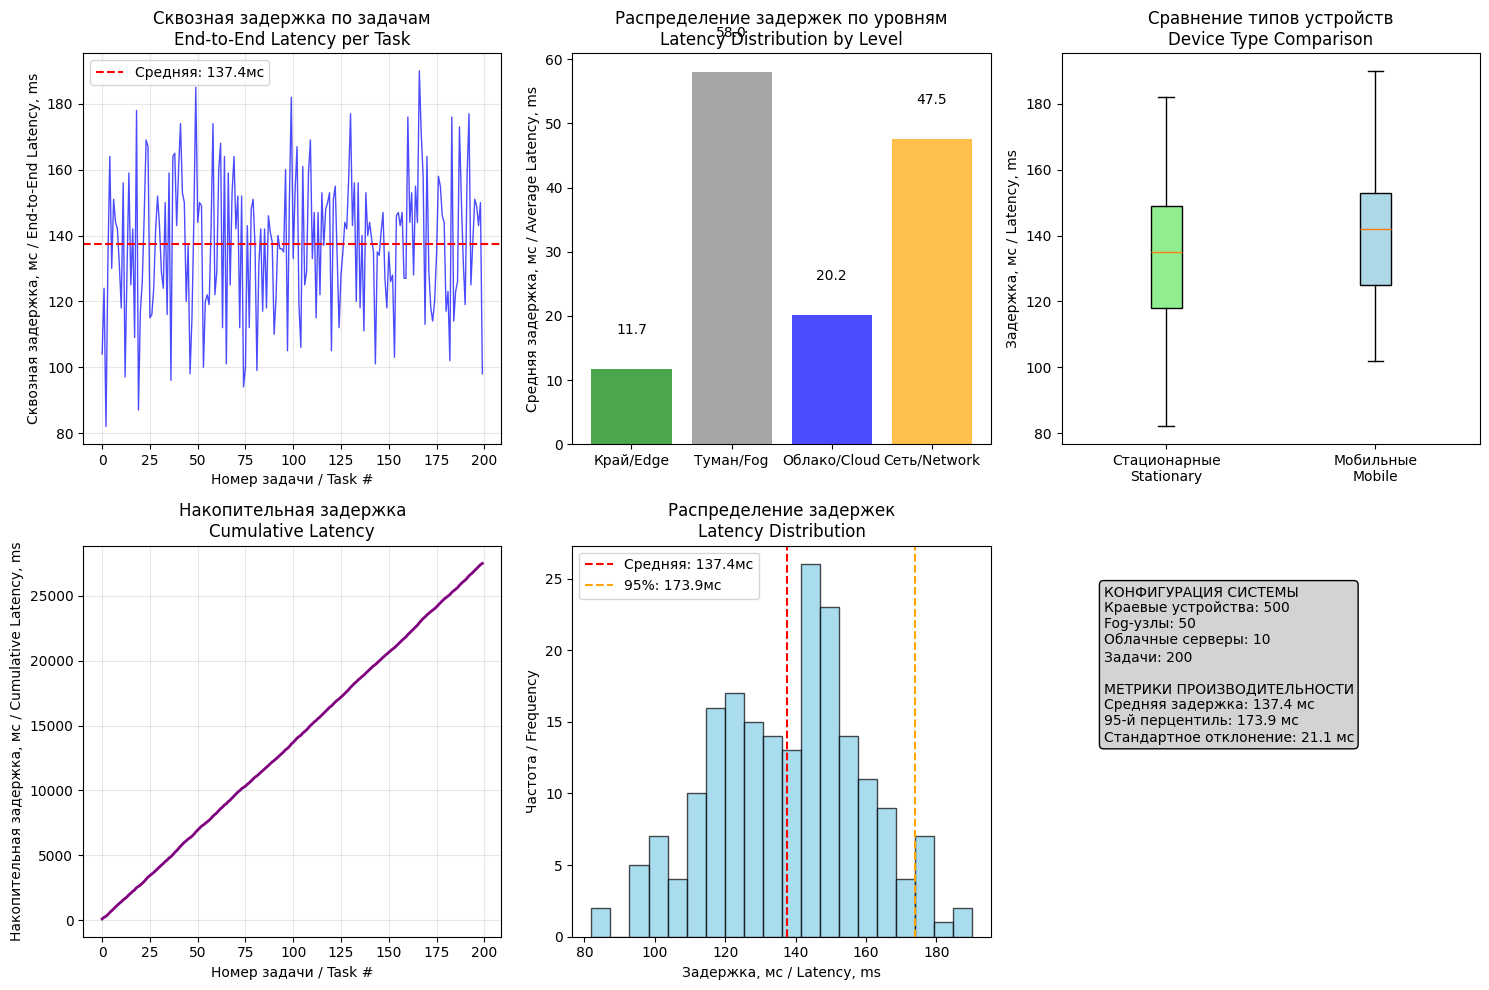


✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!
📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()


In [ ]:
"""
viz_cloud_fog_edge_pipeline_custom.py

Визуализация конвейера для эталонной архитектуры: Край → Туман → Облако
с возможностью настройки всех параметров системы

Показываем / We show:
  • Сквозная задержка "от краевого устройства до облака" для каждой задачи
  • Задержки на каждом уровне вычислений
  • Динамика очередей на Fog-узлах
  • Метрики производительности распределённой системы
"""
import random, statistics
import matplotlib.pyplot as plt
import numpy as np

class DistributedSystemSimulator:
    def __init__(self, n_edge_devices=100, n_fog_nodes=10, n_cloud_servers=3):
        self.n_edge_devices = n_edge_devices
        self.n_fog_nodes = n_fog_nodes
        self.n_cloud_servers = n_cloud_servers

        # Инициализация устройств
        self.edge_devices = self._init_edge_devices()
        self.fog_nodes = self._init_fog_nodes()
        self.cloud_servers = self._init_cloud_servers()

    def _init_edge_devices(self):
        """Инициализация краевых устройств (стационарные и мобильные)"""
        devices = []
        for i in range(self.n_edge_devices):
            device_type = "стационарный" if i % 2 == 0 else "мобильный"
            # Мобильные устройства имеют немного другие характеристики
            if device_type == "мобильный":
                processing_range = (8, 20)  # Немного выше задержка
                network_range = (8, 20)      # Менее стабильное соединение
            else:
                processing_range = (5, 15)  # Стабильная задержка
                network_range = (5, 15)      # Стабильное соединение

            devices.append({
                'id': f"Edge_{i}",
                'type': device_type,
                'processing_delay': random.randint(*processing_range),  # мс
                'network_delay': random.randint(*network_range),        # мс
                'assigned_fog': random.randint(0, self.n_fog_nodes-1)
            })
        return devices

    def _init_fog_nodes(self):
        """Инициализация Fog-узлов"""
        nodes = []
        for i in range(self.n_fog_nodes):
            # Разные Fog-узлы могут иметь разную производительность
            capacity_factor = random.uniform(0.8, 1.2)
            nodes.append({
                'id': f"Fog_{i}",
                'processing_delay_range': (int(30 * capacity_factor), int(80 * capacity_factor)),
                'queue_capacity': 400,
                'current_queue': 0,
                'assigned_cloud': random.randint(0, self.n_cloud_servers-1),
                'processed_tasks': 0
            })
        return nodes

    def _init_cloud_servers(self):
        """Инициализация облачных серверов"""
        servers = []
        for i in range(self.n_cloud_servers):
            # Облачные серверы обычно более производительные
            servers.append({
                'id': f"Cloud_{i}",
                'processing_delay_range': (10, 30),  # мс
                'storage_capacity': 1000,
                'processed_tasks': 0
            })
        return servers

def simulate_ethernet_architecture_custom(n_tasks=100, simulator=None, seed=42):
    """
    Симуляция эталонной архитектуры с кастомным симулятором
    """
    if simulator is None:
        simulator = DistributedSystemSimulator()

    random.seed(seed)
    tasks = []

    for task_id in range(n_tasks):
        # Случайное краевое устройство генерирует задачу
        edge_device = random.choice(simulator.edge_devices)
        fog_node = simulator.fog_nodes[edge_device['assigned_fog']]
        cloud_server = simulator.cloud_servers[fog_node['assigned_cloud']]

        # Задержки на каждом этапе
        edge_processing = edge_device['processing_delay']
        edge_to_fog_network = edge_device['network_delay']

        fog_processing = random.randint(*fog_node['processing_delay_range'])
        fog_queue_delay = fog_node['current_queue'] * 2  # 2 мс на задачу в очереди

        fog_to_cloud_network = random.randint(20, 50)  # Более высокая задержка до облака
        cloud_processing = random.randint(*cloud_server['processing_delay_range'])

        # Обновление очереди Fog-узла
        if fog_node['current_queue'] < fog_node['queue_capacity']:
            fog_node['current_queue'] += 1
        else:
            fog_queue_delay += 10  # Штраф за переполнение очереди

        # Общая сквозная задержка
        end_to_end_latency = (edge_processing + edge_to_fog_network +
                             fog_processing + fog_queue_delay +
                             fog_to_cloud_network + cloud_processing)

        tasks.append({
            'task_id': task_id,
            'edge_device': edge_device['id'],
            'edge_type': edge_device['type'],
            'fog_node': fog_node['id'],
            'cloud_server': cloud_server['id'],
            'edge_processing': edge_processing,
            'edge_to_fog_network': edge_to_fog_network,
            'fog_processing': fog_processing,
            'fog_queue_delay': fog_queue_delay,
            'fog_to_cloud_network': fog_to_cloud_network,
            'cloud_processing': cloud_processing,
            'end_to_end_latency': end_to_end_latency
        })

        # Уменьшение очереди Fog-узла (обработка задач)
        if random.random() < 0.3:  # 30% chance to process a task from queue
            if fog_node['current_queue'] > 0:
                fog_node['current_queue'] -= 1
                fog_node['processed_tasks'] += 1

        # Обновление статистики облачного сервера
        cloud_server['processed_tasks'] += 1

    return tasks

def analyze_performance(tasks):
    """Анализ производительности системы"""
    latencies = [task['end_to_end_latency'] for task in tasks]
    edge_latencies = [task['edge_processing'] for task in tasks]
    fog_latencies = [task['fog_processing'] + task['fog_queue_delay'] for task in tasks]
    cloud_latencies = [task['cloud_processing'] for task in tasks]
    network_latencies = [task['edge_to_fog_network'] + task['fog_to_cloud_network'] for task in tasks]

    # Статистика
    stats = {
        'avg_end_to_end': statistics.mean(latencies),
        'p95_end_to_end': statistics.quantiles(latencies, n=20)[18],
        'p99_end_to_end': statistics.quantiles(latencies, n=100)[98],
        'avg_edge': statistics.mean(edge_latencies),
        'avg_fog': statistics.mean(fog_latencies),
        'avg_cloud': statistics.mean(cloud_latencies),
        'avg_network': statistics.mean(network_latencies),
        'max_latency': max(latencies),
        'min_latency': min(latencies),
        'std_latency': statistics.stdev(latencies) if len(latencies) > 1 else 0
    }

    return stats

def plot_comprehensive_results(tasks, stats, config):
    """Построение комплексных графиков результатов"""

    plt.figure(figsize=(15, 10))

    # График 1: Сквозная задержка по задачам
    plt.subplot(2, 3, 1)
    task_ids = [task['task_id'] for task in tasks]
    latencies = [task['end_to_end_latency'] for task in tasks]
    plt.plot(task_ids, latencies, 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=stats['avg_end_to_end'], color='r', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Сквозная задержка, мс / End-to-End Latency, ms')
    plt.title('Сквозная задержка по задачам\nEnd-to-End Latency per Task')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 2: Распределение задержек по уровням
    plt.subplot(2, 3, 2)
    components = ['Край/Edge', 'Туман/Fog', 'Облако/Cloud', 'Сеть/Network']
    avg_latencies = [stats['avg_edge'], stats['avg_fog'], stats['avg_cloud'], stats['avg_network']]
    colors = ['green', 'gray', 'blue', 'orange']
    bars = plt.bar(components, avg_latencies, color=colors, alpha=0.7)
    plt.ylabel('Средняя задержка, мс / Average Latency, ms')
    plt.title('Распределение задержек по уровням\nLatency Distribution by Level')

    # Добавление значений на столбцы
    for bar, value in zip(bars, avg_latencies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom')

    # График 3: Сравнение стационарных и мобильных устройств
    plt.subplot(2, 3, 3)
    stationary_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'стационарный']
    mobile_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'мобильный']

    box_data = [stationary_latencies, mobile_latencies]
    box_labels = ['Стационарные\nStationary', 'Мобильные\nMobile']
    box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

    # Цвета для boxplot
    colors = ['lightgreen', 'lightblue']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel('Задержка, мс / Latency, ms')
    plt.title('Сравнение типов устройств\nDevice Type Comparison')

    # График 4: Накопительная задержка
    plt.subplot(2, 3, 4)
    cumulative_latency = np.cumsum([task['end_to_end_latency'] for task in tasks])
    plt.plot(task_ids, cumulative_latency, 'purple', linewidth=2)
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Накопительная задержка, мс / Cumulative Latency, ms')
    plt.title('Накопительная задержка\nCumulative Latency')
    plt.grid(True, alpha=0.3)

    # График 5: Гистограмма распределения задержек
    plt.subplot(2, 3, 5)
    plt.hist(latencies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(stats['avg_end_to_end'], color='red', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.axvline(stats['p95_end_to_end'], color='orange', linestyle='--', label=f'95%: {stats["p95_end_to_end"]:.1f}мс')
    plt.xlabel('Задержка, мс / Latency, ms')
    plt.ylabel('Частота / Frequency')
    plt.title('Распределение задержек\nLatency Distribution')
    plt.legend()

    # График 6: Информация о конфигурации
    plt.subplot(2, 3, 6)
    plt.axis('off')
    config_text = (
        f"КОНФИГУРАЦИЯ СИСТЕМЫ\n"
        f"Краевые устройства: {config['edge_devices']}\n"
        f"Fog-узлы: {config['fog_nodes']}\n"
        f"Облачные серверы: {config['cloud_servers']}\n"
        f"Задачи: {config['tasks']}\n\n"
        f"МЕТРИКИ ПРОИЗВОДИТЕЛЬНОСТИ\n"
        f"Средняя задержка: {stats['avg_end_to_end']:.1f} мс\n"
        f"95-й перцентиль: {stats['p95_end_to_end']:.1f} мс\n"
        f"Стандартное отклонение: {stats['std_latency']:.1f} мс"
    )
    plt.text(0.1, 0.9, config_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

def print_detailed_metrics(tasks, stats, config):
    """Вывод детализированных метрик"""
    print("=" * 70)
    print("МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS")
    print("=" * 70)

    print(f"\nКОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:")
    print(f"  Краевые устройства: {config['edge_devices']}")
    print(f"  Fog-узлы: {config['fog_nodes']}")
    print(f"  Облачные серверы: {config['cloud_servers']}")
    print(f"  Всего задач: {config['tasks']}")

    print(f"\nОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:")
    print(f"  Средняя сквозная задержка: {stats['avg_end_to_end']:.2f} мс")
    print(f"  95-й перцентиль задержки: {stats['p95_end_to_end']:.2f} мс")
    print(f"  99-й перцентиль задержки: {stats['p99_end_to_end']:.2f} мс")
    print(f"  Стандартное отклонение: {stats['std_latency']:.2f} мс")
    print(f"  Минимальная задержка: {stats['min_latency']:.2f} мс")
    print(f"  Максимальная задержка: {stats['max_latency']:.2f} мс")

    print(f"\nРАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:")
    print(f"  Краевой уровень (Edge): {stats['avg_edge']:.2f} мс ({stats['avg_edge']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Туманный уровень (Fog): {stats['avg_fog']:.2f} мс ({stats['avg_fog']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Облачный уровень (Cloud): {stats['avg_cloud']:.2f} мс ({stats['avg_cloud']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Сетевые задержки: {stats['avg_network']:.2f} мс ({stats['avg_network']/stats['avg_end_to_end']*100:.1f}%)")

    # Анализ по типам устройств
    stationary_tasks = [t for t in tasks if t['edge_type'] == 'стационарный']
    mobile_tasks = [t for t in tasks if t['edge_type'] == 'мобильный']

    if stationary_tasks:
        avg_stationary = statistics.mean([t['end_to_end_latency'] for t in stationary_tasks])
        print(f"\nСТАЦИОНАРНЫЕ УСТРОЙСТВА / STATIONARY DEVICES:")
        print(f"  Количество задач: {len(stationary_tasks)} ({len(stationary_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_stationary:.2f} мс")

    if mobile_tasks:
        avg_mobile = statistics.mean([t['end_to_end_latency'] for t in mobile_tasks])
        print(f"\nМОБИЛЬНЫЕ УСТРОЙСТВА / MOBILE DEVICES:")
        print(f"  Количество задач: {len(mobile_tasks)} ({len(mobile_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_mobile:.2f} мс")

def simulate_custom_config():
    """Функция для быстрой настройки конфигурации системы"""

    # 🎛️ НАСТРОЙКА ПАРАМЕТРОВ СИСТЕМЫ - МЕНЯЙТЕ ЭТИ ЧИСЛА 🎛️
    CONFIG = {
        'edge_devices': 500,      # ↦ Количество краевых устройств (100-10000)
        'fog_nodes': 50,          # ↦ Количество Fog-узлов (100-10000)
        'cloud_servers': 10,       # ↦ Количество облачных серверов (1-100)
        'tasks': 200,             # ↦ Количество задач для симуляции
        'seed': 42               # ↦ Seed для воспроизводимости результатов
    }

    print(f"⚙️  Загружена конфигурация:")
    print(f"   Краевые устройства: {CONFIG['edge_devices']}")
    print(f"   Fog-узлы: {CONFIG['fog_nodes']}")
    print(f"   Облачные серверы: {CONFIG['cloud_servers']}")
    print(f"   Задачи: {CONFIG['tasks']}")

    # Проверка корректности конфигурации
    if CONFIG['edge_devices'] < CONFIG['fog_nodes']:
        print("⚠️  Предупреждение: Fog-узлов больше чем краевых устройств")

    if CONFIG['fog_nodes'] < CONFIG['cloud_servers']:
        print("⚠️  Предупреждение: Облачных серверов больше чем Fog-узлов")

    # Инициализация симулятора
    simulator = DistributedSystemSimulator(
        n_edge_devices=CONFIG['edge_devices'],
        n_fog_nodes=CONFIG['fog_nodes'],
        n_cloud_servers=CONFIG['cloud_servers']
    )

    # Запуск симуляции
    tasks = simulate_ethernet_architecture_custom(
        n_tasks=CONFIG['tasks'],
        simulator=simulator,
        seed=CONFIG['seed']
    )

    return tasks, simulator, CONFIG

def main():
    """Основная функция с настраиваемыми параметрами"""

    print("🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО")
    print("🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD")
    print("-" * 70)

    # Запуск симуляции с кастомной конфигурацией
    tasks, simulator, config = simulate_custom_config()

    # Анализ производительности
    stats = analyze_performance(tasks)

    # Вывод результатов
    print_detailed_metrics(tasks, stats, config)

    # Построение графиков
    plot_comprehensive_results(tasks, stats, config)

    print(f"\n✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
    print(f"📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()")

if __name__ == '__main__':
    main()

Крупный масштаб

🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО
🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD
----------------------------------------------------------------------
⚙️  Загружена конфигурация:
   Краевые устройства: 2000
   Fog-узлы: 200
   Облачные серверы: 20
   Задачи: 200
МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS

КОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:
  Краевые устройства: 2000
  Fog-узлы: 200
  Облачные серверы: 20
  Всего задач: 200

ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:
  Средняя сквозная задержка: 136.34 мс
  95-й перцентиль задержки: 168.00 мс
  99-й перцентиль задержки: 179.99 мс
  Стандартное отклонение: 19.92 мс
  Минимальная задержка: 79.00 мс
  Максимальная задержка: 181.00 мс

РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:
  Краевой уровень (Edge): 12.38 мс (9.1%)
  Туманный уровень (Fog): 56.10 мс (41.1%)
  Облачный уровень (Cloud): 19.76 мс (14.5%)
  Сетевые задержки: 48.10 мс (35.3%)

СТАЦИОНАРНЫЕ УСТРОЙСТВА / S

/tmp/ipython-input-1387040932.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


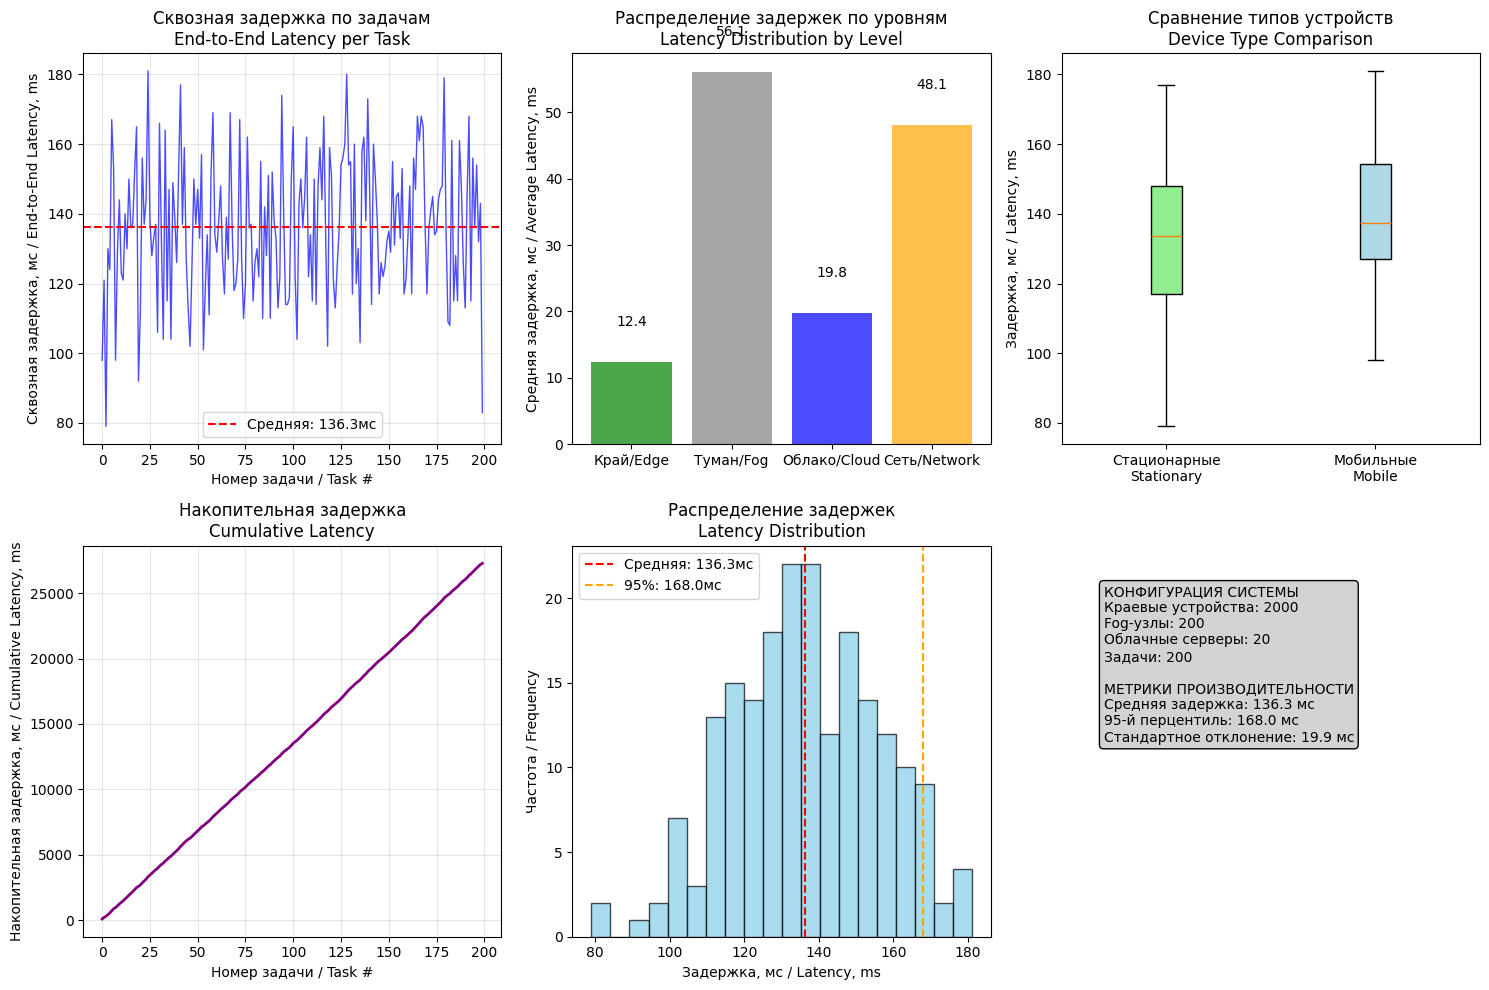


✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!
📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()


In [ ]:
"""
viz_cloud_fog_edge_pipeline_custom.py

Визуализация конвейера для эталонной архитектуры: Край → Туман → Облако
с возможностью настройки всех параметров системы

Показываем / We show:
  • Сквозная задержка "от краевого устройства до облака" для каждой задачи
  • Задержки на каждом уровне вычислений
  • Динамика очередей на Fog-узлах
  • Метрики производительности распределённой системы
"""
import random, statistics
import matplotlib.pyplot as plt
import numpy as np

class DistributedSystemSimulator:
    def __init__(self, n_edge_devices=100, n_fog_nodes=10, n_cloud_servers=3):
        self.n_edge_devices = n_edge_devices
        self.n_fog_nodes = n_fog_nodes
        self.n_cloud_servers = n_cloud_servers

        # Инициализация устройств
        self.edge_devices = self._init_edge_devices()
        self.fog_nodes = self._init_fog_nodes()
        self.cloud_servers = self._init_cloud_servers()

    def _init_edge_devices(self):
        """Инициализация краевых устройств (стационарные и мобильные)"""
        devices = []
        for i in range(self.n_edge_devices):
            device_type = "стационарный" if i % 2 == 0 else "мобильный"
            # Мобильные устройства имеют немного другие характеристики
            if device_type == "мобильный":
                processing_range = (8, 20)  # Немного выше задержка
                network_range = (8, 20)      # Менее стабильное соединение
            else:
                processing_range = (5, 15)  # Стабильная задержка
                network_range = (5, 15)      # Стабильное соединение

            devices.append({
                'id': f"Edge_{i}",
                'type': device_type,
                'processing_delay': random.randint(*processing_range),  # мс
                'network_delay': random.randint(*network_range),        # мс
                'assigned_fog': random.randint(0, self.n_fog_nodes-1)
            })
        return devices

    def _init_fog_nodes(self):
        """Инициализация Fog-узлов"""
        nodes = []
        for i in range(self.n_fog_nodes):
            # Разные Fog-узлы могут иметь разную производительность
            capacity_factor = random.uniform(0.8, 1.2)
            nodes.append({
                'id': f"Fog_{i}",
                'processing_delay_range': (int(30 * capacity_factor), int(80 * capacity_factor)),
                'queue_capacity': 400,
                'current_queue': 0,
                'assigned_cloud': random.randint(0, self.n_cloud_servers-1),
                'processed_tasks': 0
            })
        return nodes

    def _init_cloud_servers(self):
        """Инициализация облачных серверов"""
        servers = []
        for i in range(self.n_cloud_servers):
            # Облачные серверы обычно более производительные
            servers.append({
                'id': f"Cloud_{i}",
                'processing_delay_range': (10, 30),  # мс
                'storage_capacity': 1000,
                'processed_tasks': 0
            })
        return servers

def simulate_ethernet_architecture_custom(n_tasks=100, simulator=None, seed=42):
    """
    Симуляция эталонной архитектуры с кастомным симулятором
    """
    if simulator is None:
        simulator = DistributedSystemSimulator()

    random.seed(seed)
    tasks = []

    for task_id in range(n_tasks):
        # Случайное краевое устройство генерирует задачу
        edge_device = random.choice(simulator.edge_devices)
        fog_node = simulator.fog_nodes[edge_device['assigned_fog']]
        cloud_server = simulator.cloud_servers[fog_node['assigned_cloud']]

        # Задержки на каждом этапе
        edge_processing = edge_device['processing_delay']
        edge_to_fog_network = edge_device['network_delay']

        fog_processing = random.randint(*fog_node['processing_delay_range'])
        fog_queue_delay = fog_node['current_queue'] * 2  # 2 мс на задачу в очереди

        fog_to_cloud_network = random.randint(20, 50)  # Более высокая задержка до облака
        cloud_processing = random.randint(*cloud_server['processing_delay_range'])

        # Обновление очереди Fog-узла
        if fog_node['current_queue'] < fog_node['queue_capacity']:
            fog_node['current_queue'] += 1
        else:
            fog_queue_delay += 10  # Штраф за переполнение очереди

        # Общая сквозная задержка
        end_to_end_latency = (edge_processing + edge_to_fog_network +
                             fog_processing + fog_queue_delay +
                             fog_to_cloud_network + cloud_processing)

        tasks.append({
            'task_id': task_id,
            'edge_device': edge_device['id'],
            'edge_type': edge_device['type'],
            'fog_node': fog_node['id'],
            'cloud_server': cloud_server['id'],
            'edge_processing': edge_processing,
            'edge_to_fog_network': edge_to_fog_network,
            'fog_processing': fog_processing,
            'fog_queue_delay': fog_queue_delay,
            'fog_to_cloud_network': fog_to_cloud_network,
            'cloud_processing': cloud_processing,
            'end_to_end_latency': end_to_end_latency
        })

        # Уменьшение очереди Fog-узла (обработка задач)
        if random.random() < 0.3:  # 30% chance to process a task from queue
            if fog_node['current_queue'] > 0:
                fog_node['current_queue'] -= 1
                fog_node['processed_tasks'] += 1

        # Обновление статистики облачного сервера
        cloud_server['processed_tasks'] += 1

    return tasks

def analyze_performance(tasks):
    """Анализ производительности системы"""
    latencies = [task['end_to_end_latency'] for task in tasks]
    edge_latencies = [task['edge_processing'] for task in tasks]
    fog_latencies = [task['fog_processing'] + task['fog_queue_delay'] for task in tasks]
    cloud_latencies = [task['cloud_processing'] for task in tasks]
    network_latencies = [task['edge_to_fog_network'] + task['fog_to_cloud_network'] for task in tasks]

    # Статистика
    stats = {
        'avg_end_to_end': statistics.mean(latencies),
        'p95_end_to_end': statistics.quantiles(latencies, n=20)[18],
        'p99_end_to_end': statistics.quantiles(latencies, n=100)[98],
        'avg_edge': statistics.mean(edge_latencies),
        'avg_fog': statistics.mean(fog_latencies),
        'avg_cloud': statistics.mean(cloud_latencies),
        'avg_network': statistics.mean(network_latencies),
        'max_latency': max(latencies),
        'min_latency': min(latencies),
        'std_latency': statistics.stdev(latencies) if len(latencies) > 1 else 0
    }

    return stats

def plot_comprehensive_results(tasks, stats, config):
    """Построение комплексных графиков результатов"""

    plt.figure(figsize=(15, 10))

    # График 1: Сквозная задержка по задачам
    plt.subplot(2, 3, 1)
    task_ids = [task['task_id'] for task in tasks]
    latencies = [task['end_to_end_latency'] for task in tasks]
    plt.plot(task_ids, latencies, 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=stats['avg_end_to_end'], color='r', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Сквозная задержка, мс / End-to-End Latency, ms')
    plt.title('Сквозная задержка по задачам\nEnd-to-End Latency per Task')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 2: Распределение задержек по уровням
    plt.subplot(2, 3, 2)
    components = ['Край/Edge', 'Туман/Fog', 'Облако/Cloud', 'Сеть/Network']
    avg_latencies = [stats['avg_edge'], stats['avg_fog'], stats['avg_cloud'], stats['avg_network']]
    colors = ['green', 'gray', 'blue', 'orange']
    bars = plt.bar(components, avg_latencies, color=colors, alpha=0.7)
    plt.ylabel('Средняя задержка, мс / Average Latency, ms')
    plt.title('Распределение задержек по уровням\nLatency Distribution by Level')

    # Добавление значений на столбцы
    for bar, value in zip(bars, avg_latencies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom')

    # График 3: Сравнение стационарных и мобильных устройств
    plt.subplot(2, 3, 3)
    stationary_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'стационарный']
    mobile_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'мобильный']

    box_data = [stationary_latencies, mobile_latencies]
    box_labels = ['Стационарные\nStationary', 'Мобильные\nMobile']
    box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

    # Цвета для boxplot
    colors = ['lightgreen', 'lightblue']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel('Задержка, мс / Latency, ms')
    plt.title('Сравнение типов устройств\nDevice Type Comparison')

    # График 4: Накопительная задержка
    plt.subplot(2, 3, 4)
    cumulative_latency = np.cumsum([task['end_to_end_latency'] for task in tasks])
    plt.plot(task_ids, cumulative_latency, 'purple', linewidth=2)
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Накопительная задержка, мс / Cumulative Latency, ms')
    plt.title('Накопительная задержка\nCumulative Latency')
    plt.grid(True, alpha=0.3)

    # График 5: Гистограмма распределения задержек
    plt.subplot(2, 3, 5)
    plt.hist(latencies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(stats['avg_end_to_end'], color='red', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.axvline(stats['p95_end_to_end'], color='orange', linestyle='--', label=f'95%: {stats["p95_end_to_end"]:.1f}мс')
    plt.xlabel('Задержка, мс / Latency, ms')
    plt.ylabel('Частота / Frequency')
    plt.title('Распределение задержек\nLatency Distribution')
    plt.legend()

    # График 6: Информация о конфигурации
    plt.subplot(2, 3, 6)
    plt.axis('off')
    config_text = (
        f"КОНФИГУРАЦИЯ СИСТЕМЫ\n"
        f"Краевые устройства: {config['edge_devices']}\n"
        f"Fog-узлы: {config['fog_nodes']}\n"
        f"Облачные серверы: {config['cloud_servers']}\n"
        f"Задачи: {config['tasks']}\n\n"
        f"МЕТРИКИ ПРОИЗВОДИТЕЛЬНОСТИ\n"
        f"Средняя задержка: {stats['avg_end_to_end']:.1f} мс\n"
        f"95-й перцентиль: {stats['p95_end_to_end']:.1f} мс\n"
        f"Стандартное отклонение: {stats['std_latency']:.1f} мс"
    )
    plt.text(0.1, 0.9, config_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

def print_detailed_metrics(tasks, stats, config):
    """Вывод детализированных метрик"""
    print("=" * 70)
    print("МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS")
    print("=" * 70)

    print(f"\nКОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:")
    print(f"  Краевые устройства: {config['edge_devices']}")
    print(f"  Fog-узлы: {config['fog_nodes']}")
    print(f"  Облачные серверы: {config['cloud_servers']}")
    print(f"  Всего задач: {config['tasks']}")

    print(f"\nОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:")
    print(f"  Средняя сквозная задержка: {stats['avg_end_to_end']:.2f} мс")
    print(f"  95-й перцентиль задержки: {stats['p95_end_to_end']:.2f} мс")
    print(f"  99-й перцентиль задержки: {stats['p99_end_to_end']:.2f} мс")
    print(f"  Стандартное отклонение: {stats['std_latency']:.2f} мс")
    print(f"  Минимальная задержка: {stats['min_latency']:.2f} мс")
    print(f"  Максимальная задержка: {stats['max_latency']:.2f} мс")

    print(f"\nРАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:")
    print(f"  Краевой уровень (Edge): {stats['avg_edge']:.2f} мс ({stats['avg_edge']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Туманный уровень (Fog): {stats['avg_fog']:.2f} мс ({stats['avg_fog']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Облачный уровень (Cloud): {stats['avg_cloud']:.2f} мс ({stats['avg_cloud']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Сетевые задержки: {stats['avg_network']:.2f} мс ({stats['avg_network']/stats['avg_end_to_end']*100:.1f}%)")

    # Анализ по типам устройств
    stationary_tasks = [t for t in tasks if t['edge_type'] == 'стационарный']
    mobile_tasks = [t for t in tasks if t['edge_type'] == 'мобильный']

    if stationary_tasks:
        avg_stationary = statistics.mean([t['end_to_end_latency'] for t in stationary_tasks])
        print(f"\nСТАЦИОНАРНЫЕ УСТРОЙСТВА / STATIONARY DEVICES:")
        print(f"  Количество задач: {len(stationary_tasks)} ({len(stationary_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_stationary:.2f} мс")

    if mobile_tasks:
        avg_mobile = statistics.mean([t['end_to_end_latency'] for t in mobile_tasks])
        print(f"\nМОБИЛЬНЫЕ УСТРОЙСТВА / MOBILE DEVICES:")
        print(f"  Количество задач: {len(mobile_tasks)} ({len(mobile_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_mobile:.2f} мс")

def simulate_custom_config():
    """Функция для быстрой настройки конфигурации системы"""

    # 🎛️ НАСТРОЙКА ПАРАМЕТРОВ СИСТЕМЫ - МЕНЯЙТЕ ЭТИ ЧИСЛА 🎛️
    CONFIG = {
        'edge_devices': 2000,      # ↦ Количество краевых устройств (100-10000)
        'fog_nodes': 200,          # ↦ Количество Fog-узлов (100-10000)
        'cloud_servers': 20,       # ↦ Количество облачных серверов (1-100)
        'tasks': 200,             # ↦ Количество задач для симуляции
        'seed': 42               # ↦ Seed для воспроизводимости результатов
    }

    print(f"⚙️  Загружена конфигурация:")
    print(f"   Краевые устройства: {CONFIG['edge_devices']}")
    print(f"   Fog-узлы: {CONFIG['fog_nodes']}")
    print(f"   Облачные серверы: {CONFIG['cloud_servers']}")
    print(f"   Задачи: {CONFIG['tasks']}")

    # Проверка корректности конфигурации
    if CONFIG['edge_devices'] < CONFIG['fog_nodes']:
        print("⚠️  Предупреждение: Fog-узлов больше чем краевых устройств")

    if CONFIG['fog_nodes'] < CONFIG['cloud_servers']:
        print("⚠️  Предупреждение: Облачных серверов больше чем Fog-узлов")

    # Инициализация симулятора
    simulator = DistributedSystemSimulator(
        n_edge_devices=CONFIG['edge_devices'],
        n_fog_nodes=CONFIG['fog_nodes'],
        n_cloud_servers=CONFIG['cloud_servers']
    )

    # Запуск симуляции
    tasks = simulate_ethernet_architecture_custom(
        n_tasks=CONFIG['tasks'],
        simulator=simulator,
        seed=CONFIG['seed']
    )

    return tasks, simulator, CONFIG

def main():
    """Основная функция с настраиваемыми параметрами"""

    print("🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО")
    print("🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD")
    print("-" * 70)

    # Запуск симуляции с кастомной конфигурацией
    tasks, simulator, config = simulate_custom_config()

    # Анализ производительности
    stats = analyze_performance(tasks)

    # Вывод результатов
    print_detailed_metrics(tasks, stats, config)

    # Построение графиков
    plot_comprehensive_results(tasks, stats, config)

    print(f"\n✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
    print(f"📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()")

if __name__ == '__main__':
    main()

Индивидуальное задание

🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО
🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD
----------------------------------------------------------------------
⚙️  Загружена конфигурация:
   Краевые устройства: 5000
   Fog-узлы: 200
   Облачные серверы: 20
   Задачи: 200
МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS

КОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:
  Краевые устройства: 5000
  Fog-узлы: 200
  Облачные серверы: 20
  Всего задач: 200

ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:
  Средняя сквозная задержка: 133.76 мс
  95-й перцентиль задержки: 170.00 мс
  99-й перцентиль задержки: 182.97 мс
  Стандартное отклонение: 21.34 мс
  Минимальная задержка: 75.00 мс
  Максимальная задержка: 185.00 мс

РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:
  Краевой уровень (Edge): 12.04 мс (9.0%)
  Туманный уровень (Fog): 54.84 мс (41.0%)
  Облачный уровень (Cloud): 20.71 мс (15.5%)
  Сетевые задержки: 46.17 мс (34.5%)

СТАЦИОНАРНЫЕ УСТРОЙСТВА / S

/tmp/ipython-input-2914006570.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


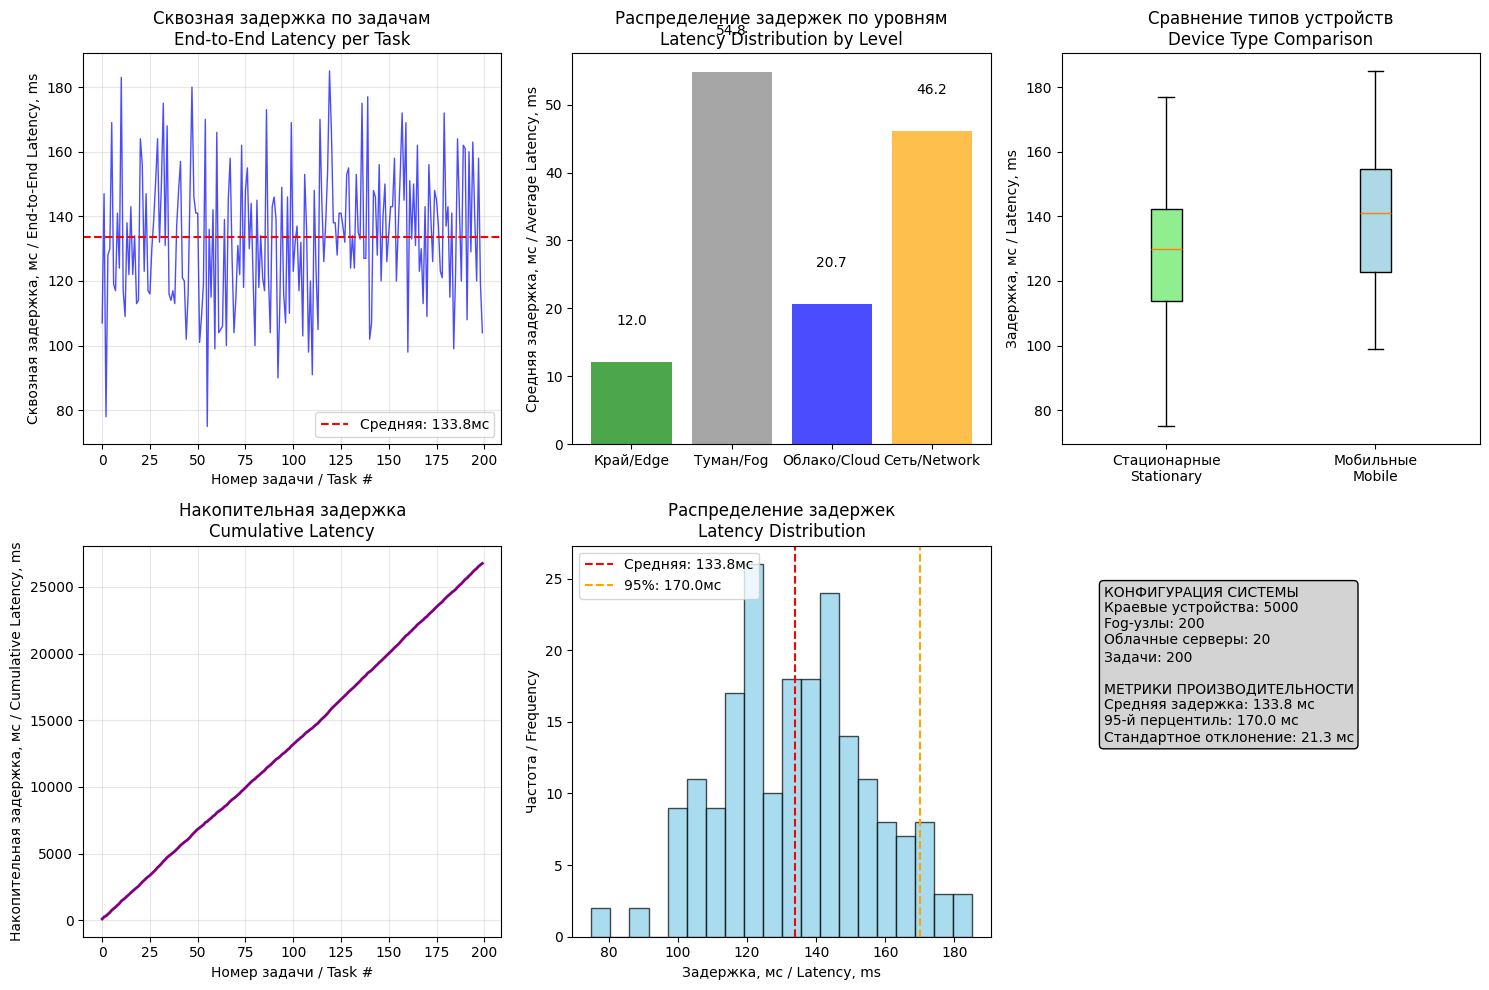


✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!
📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()


In [ ]:
"""
viz_cloud_fog_edge_pipeline_custom.py

Визуализация конвейера для эталонной архитектуры: Край → Туман → Облако
с возможностью настройки всех параметров системы

Показываем / We show:
  • Сквозная задержка "от краевого устройства до облака" для каждой задачи
  • Задержки на каждом уровне вычислений
  • Динамика очередей на Fog-узлах
  • Метрики производительности распределённой системы
"""
import random, statistics
import matplotlib.pyplot as plt
import numpy as np

class DistributedSystemSimulator:
    def __init__(self, n_edge_devices=100, n_fog_nodes=10, n_cloud_servers=3):
        self.n_edge_devices = n_edge_devices
        self.n_fog_nodes = n_fog_nodes
        self.n_cloud_servers = n_cloud_servers

        # Инициализация устройств
        self.edge_devices = self._init_edge_devices()
        self.fog_nodes = self._init_fog_nodes()
        self.cloud_servers = self._init_cloud_servers()

    def _init_edge_devices(self):
        """Инициализация краевых устройств (стационарные и мобильные)"""
        devices = []
        for i in range(self.n_edge_devices):
            device_type = "стационарный" if i % 2 == 0 else "мобильный"
            # Мобильные устройства имеют немного другие характеристики
            if device_type == "мобильный":
                processing_range = (8, 20)  # Немного выше задержка
                network_range = (8, 20)      # Менее стабильное соединение
            else:
                processing_range = (5, 15)  # Стабильная задержка
                network_range = (5, 15)      # Стабильное соединение

            devices.append({
                'id': f"Edge_{i}",
                'type': device_type,
                'processing_delay': random.randint(*processing_range),  # мс
                'network_delay': random.randint(*network_range),        # мс
                'assigned_fog': random.randint(0, self.n_fog_nodes-1)
            })
        return devices

    def _init_fog_nodes(self):
        """Инициализация Fog-узлов"""
        nodes = []
        for i in range(self.n_fog_nodes):
            # Разные Fog-узлы могут иметь разную производительность
            capacity_factor = random.uniform(0.8, 1.2)
            nodes.append({
                'id': f"Fog_{i}",
                'processing_delay_range': (int(30 * capacity_factor), int(80 * capacity_factor)),
                'queue_capacity': 400,
                'current_queue': 0,
                'assigned_cloud': random.randint(0, self.n_cloud_servers-1),
                'processed_tasks': 0
            })
        return nodes

    def _init_cloud_servers(self):
        """Инициализация облачных серверов"""
        servers = []
        for i in range(self.n_cloud_servers):
            # Облачные серверы обычно более производительные
            servers.append({
                'id': f"Cloud_{i}",
                'processing_delay_range': (10, 30),  # мс
                'storage_capacity': 1000,
                'processed_tasks': 0
            })
        return servers

def simulate_ethernet_architecture_custom(n_tasks=100, simulator=None, seed=42):
    """
    Симуляция эталонной архитектуры с кастомным симулятором
    """
    if simulator is None:
        simulator = DistributedSystemSimulator()

    random.seed(seed)
    tasks = []

    for task_id in range(n_tasks):
        # Случайное краевое устройство генерирует задачу
        edge_device = random.choice(simulator.edge_devices)
        fog_node = simulator.fog_nodes[edge_device['assigned_fog']]
        cloud_server = simulator.cloud_servers[fog_node['assigned_cloud']]

        # Задержки на каждом этапе
        edge_processing = edge_device['processing_delay']
        edge_to_fog_network = edge_device['network_delay']

        fog_processing = random.randint(*fog_node['processing_delay_range'])
        fog_queue_delay = fog_node['current_queue'] * 2  # 2 мс на задачу в очереди

        fog_to_cloud_network = random.randint(20, 50)  # Более высокая задержка до облака
        cloud_processing = random.randint(*cloud_server['processing_delay_range'])

        # Обновление очереди Fog-узла
        if fog_node['current_queue'] < fog_node['queue_capacity']:
            fog_node['current_queue'] += 1
        else:
            fog_queue_delay += 10  # Штраф за переполнение очереди

        # Общая сквозная задержка
        end_to_end_latency = (edge_processing + edge_to_fog_network +
                             fog_processing + fog_queue_delay +
                             fog_to_cloud_network + cloud_processing)

        tasks.append({
            'task_id': task_id,
            'edge_device': edge_device['id'],
            'edge_type': edge_device['type'],
            'fog_node': fog_node['id'],
            'cloud_server': cloud_server['id'],
            'edge_processing': edge_processing,
            'edge_to_fog_network': edge_to_fog_network,
            'fog_processing': fog_processing,
            'fog_queue_delay': fog_queue_delay,
            'fog_to_cloud_network': fog_to_cloud_network,
            'cloud_processing': cloud_processing,
            'end_to_end_latency': end_to_end_latency
        })

        # Уменьшение очереди Fog-узла (обработка задач)
        if random.random() < 0.3:  # 30% chance to process a task from queue
            if fog_node['current_queue'] > 0:
                fog_node['current_queue'] -= 1
                fog_node['processed_tasks'] += 1

        # Обновление статистики облачного сервера
        cloud_server['processed_tasks'] += 1

    return tasks

def analyze_performance(tasks):
    """Анализ производительности системы"""
    latencies = [task['end_to_end_latency'] for task in tasks]
    edge_latencies = [task['edge_processing'] for task in tasks]
    fog_latencies = [task['fog_processing'] + task['fog_queue_delay'] for task in tasks]
    cloud_latencies = [task['cloud_processing'] for task in tasks]
    network_latencies = [task['edge_to_fog_network'] + task['fog_to_cloud_network'] for task in tasks]

    # Статистика
    stats = {
        'avg_end_to_end': statistics.mean(latencies),
        'p95_end_to_end': statistics.quantiles(latencies, n=20)[18],
        'p99_end_to_end': statistics.quantiles(latencies, n=100)[98],
        'avg_edge': statistics.mean(edge_latencies),
        'avg_fog': statistics.mean(fog_latencies),
        'avg_cloud': statistics.mean(cloud_latencies),
        'avg_network': statistics.mean(network_latencies),
        'max_latency': max(latencies),
        'min_latency': min(latencies),
        'std_latency': statistics.stdev(latencies) if len(latencies) > 1 else 0
    }

    return stats

def plot_comprehensive_results(tasks, stats, config):
    """Построение комплексных графиков результатов"""

    plt.figure(figsize=(15, 10))

    # График 1: Сквозная задержка по задачам
    plt.subplot(2, 3, 1)
    task_ids = [task['task_id'] for task in tasks]
    latencies = [task['end_to_end_latency'] for task in tasks]
    plt.plot(task_ids, latencies, 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=stats['avg_end_to_end'], color='r', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Сквозная задержка, мс / End-to-End Latency, ms')
    plt.title('Сквозная задержка по задачам\nEnd-to-End Latency per Task')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 2: Распределение задержек по уровням
    plt.subplot(2, 3, 2)
    components = ['Край/Edge', 'Туман/Fog', 'Облако/Cloud', 'Сеть/Network']
    avg_latencies = [stats['avg_edge'], stats['avg_fog'], stats['avg_cloud'], stats['avg_network']]
    colors = ['green', 'gray', 'blue', 'orange']
    bars = plt.bar(components, avg_latencies, color=colors, alpha=0.7)
    plt.ylabel('Средняя задержка, мс / Average Latency, ms')
    plt.title('Распределение задержек по уровням\nLatency Distribution by Level')

    # Добавление значений на столбцы
    for bar, value in zip(bars, avg_latencies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom')

    # График 3: Сравнение стационарных и мобильных устройств
    plt.subplot(2, 3, 3)
    stationary_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'стационарный']
    mobile_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'мобильный']

    box_data = [stationary_latencies, mobile_latencies]
    box_labels = ['Стационарные\nStationary', 'Мобильные\nMobile']
    box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

    # Цвета для boxplot
    colors = ['lightgreen', 'lightblue']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel('Задержка, мс / Latency, ms')
    plt.title('Сравнение типов устройств\nDevice Type Comparison')

    # График 4: Накопительная задержка
    plt.subplot(2, 3, 4)
    cumulative_latency = np.cumsum([task['end_to_end_latency'] for task in tasks])
    plt.plot(task_ids, cumulative_latency, 'purple', linewidth=2)
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Накопительная задержка, мс / Cumulative Latency, ms')
    plt.title('Накопительная задержка\nCumulative Latency')
    plt.grid(True, alpha=0.3)

    # График 5: Гистограмма распределения задержек
    plt.subplot(2, 3, 5)
    plt.hist(latencies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(stats['avg_end_to_end'], color='red', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.axvline(stats['p95_end_to_end'], color='orange', linestyle='--', label=f'95%: {stats["p95_end_to_end"]:.1f}мс')
    plt.xlabel('Задержка, мс / Latency, ms')
    plt.ylabel('Частота / Frequency')
    plt.title('Распределение задержек\nLatency Distribution')
    plt.legend()

    # График 6: Информация о конфигурации
    plt.subplot(2, 3, 6)
    plt.axis('off')
    config_text = (
        f"КОНФИГУРАЦИЯ СИСТЕМЫ\n"
        f"Краевые устройства: {config['edge_devices']}\n"
        f"Fog-узлы: {config['fog_nodes']}\n"
        f"Облачные серверы: {config['cloud_servers']}\n"
        f"Задачи: {config['tasks']}\n\n"
        f"МЕТРИКИ ПРОИЗВОДИТЕЛЬНОСТИ\n"
        f"Средняя задержка: {stats['avg_end_to_end']:.1f} мс\n"
        f"95-й перцентиль: {stats['p95_end_to_end']:.1f} мс\n"
        f"Стандартное отклонение: {stats['std_latency']:.1f} мс"
    )
    plt.text(0.1, 0.9, config_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

def print_detailed_metrics(tasks, stats, config):
    """Вывод детализированных метрик"""
    print("=" * 70)
    print("МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS")
    print("=" * 70)

    print(f"\nКОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:")
    print(f"  Краевые устройства: {config['edge_devices']}")
    print(f"  Fog-узлы: {config['fog_nodes']}")
    print(f"  Облачные серверы: {config['cloud_servers']}")
    print(f"  Всего задач: {config['tasks']}")

    print(f"\nОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:")
    print(f"  Средняя сквозная задержка: {stats['avg_end_to_end']:.2f} мс")
    print(f"  95-й перцентиль задержки: {stats['p95_end_to_end']:.2f} мс")
    print(f"  99-й перцентиль задержки: {stats['p99_end_to_end']:.2f} мс")
    print(f"  Стандартное отклонение: {stats['std_latency']:.2f} мс")
    print(f"  Минимальная задержка: {stats['min_latency']:.2f} мс")
    print(f"  Максимальная задержка: {stats['max_latency']:.2f} мс")

    print(f"\nРАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:")
    print(f"  Краевой уровень (Edge): {stats['avg_edge']:.2f} мс ({stats['avg_edge']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Туманный уровень (Fog): {stats['avg_fog']:.2f} мс ({stats['avg_fog']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Облачный уровень (Cloud): {stats['avg_cloud']:.2f} мс ({stats['avg_cloud']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Сетевые задержки: {stats['avg_network']:.2f} мс ({stats['avg_network']/stats['avg_end_to_end']*100:.1f}%)")

    # Анализ по типам устройств
    stationary_tasks = [t for t in tasks if t['edge_type'] == 'стационарный']
    mobile_tasks = [t for t in tasks if t['edge_type'] == 'мобильный']

    if stationary_tasks:
        avg_stationary = statistics.mean([t['end_to_end_latency'] for t in stationary_tasks])
        print(f"\nСТАЦИОНАРНЫЕ УСТРОЙСТВА / STATIONARY DEVICES:")
        print(f"  Количество задач: {len(stationary_tasks)} ({len(stationary_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_stationary:.2f} мс")

    if mobile_tasks:
        avg_mobile = statistics.mean([t['end_to_end_latency'] for t in mobile_tasks])
        print(f"\nМОБИЛЬНЫЕ УСТРОЙСТВА / MOBILE DEVICES:")
        print(f"  Количество задач: {len(mobile_tasks)} ({len(mobile_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_mobile:.2f} мс")

def simulate_custom_config():
    """Функция для быстрой настройки конфигурации системы"""

    # 🎛️ НАСТРОЙКА ПАРАМЕТРОВ СИСТЕМЫ - МЕНЯЙТЕ ЭТИ ЧИСЛА 🎛️
    CONFIG = {
        'edge_devices': 5000,      # ↦ Количество краевых устройств (100-10000)
        'fog_nodes': 200,          # ↦ Количество Fog-узлов (100-10000)
        'cloud_servers': 20,       # ↦ Количество облачных серверов (1-100)
        'tasks': 200,             # ↦ Количество задач для симуляции
        'seed': 42               # ↦ Seed для воспроизводимости результатов
    }

    print(f"⚙️  Загружена конфигурация:")
    print(f"   Краевые устройства: {CONFIG['edge_devices']}")
    print(f"   Fog-узлы: {CONFIG['fog_nodes']}")
    print(f"   Облачные серверы: {CONFIG['cloud_servers']}")
    print(f"   Задачи: {CONFIG['tasks']}")

    # Проверка корректности конфигурации
    if CONFIG['edge_devices'] < CONFIG['fog_nodes']:
        print("⚠️  Предупреждение: Fog-узлов больше чем краевых устройств")

    if CONFIG['fog_nodes'] < CONFIG['cloud_servers']:
        print("⚠️  Предупреждение: Облачных серверов больше чем Fog-узлов")

    # Инициализация симулятора
    simulator = DistributedSystemSimulator(
        n_edge_devices=CONFIG['edge_devices'],
        n_fog_nodes=CONFIG['fog_nodes'],
        n_cloud_servers=CONFIG['cloud_servers']
    )

    # Запуск симуляции
    tasks = simulate_ethernet_architecture_custom(
        n_tasks=CONFIG['tasks'],
        simulator=simulator,
        seed=CONFIG['seed']
    )

    return tasks, simulator, CONFIG

def main():
    """Основная функция с настраиваемыми параметрами"""

    print("🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО")
    print("🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD")
    print("-" * 70)

    # Запуск симуляции с кастомной конфигурацией
    tasks, simulator, config = simulate_custom_config()

    # Анализ производительности
    stats = analyze_performance(tasks)

    # Вывод результатов
    print_detailed_metrics(tasks, stats, config)

    # Построение графиков
    plot_comprehensive_results(tasks, stats, config)

    print(f"\n✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
    print(f"📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()")

if __name__ == '__main__':
    main()

Вместимость очереди

🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО
🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD
----------------------------------------------------------------------
⚙️  Загружена конфигурация:
   Краевые устройства: 5000
   Fog-узлы: 200
   Облачные серверы: 20
   Задачи: 200
МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS

КОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:
  Краевые устройства: 5000
  Fog-узлы: 200
  Облачные серверы: 20
  Всего задач: 200

ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:
  Средняя сквозная задержка: 132.31 мс
  95-й перцентиль задержки: 165.90 мс
  99-й перцентиль задержки: 184.98 мс
  Стандартное отклонение: 20.56 мс
  Минимальная задержка: 89.00 мс
  Максимальная задержка: 187.00 мс

РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:
  Краевой уровень (Edge): 11.99 мс (9.1%)
  Туманный уровень (Fog): 54.17 мс (40.9%)
  Облачный уровень (Cloud): 20.18 мс (15.2%)
  Сетевые задержки: 45.96 мс (34.7%)

СТАЦИОНАРНЫЕ УСТРОЙСТВА / S

/tmp/ipython-input-2507062115.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


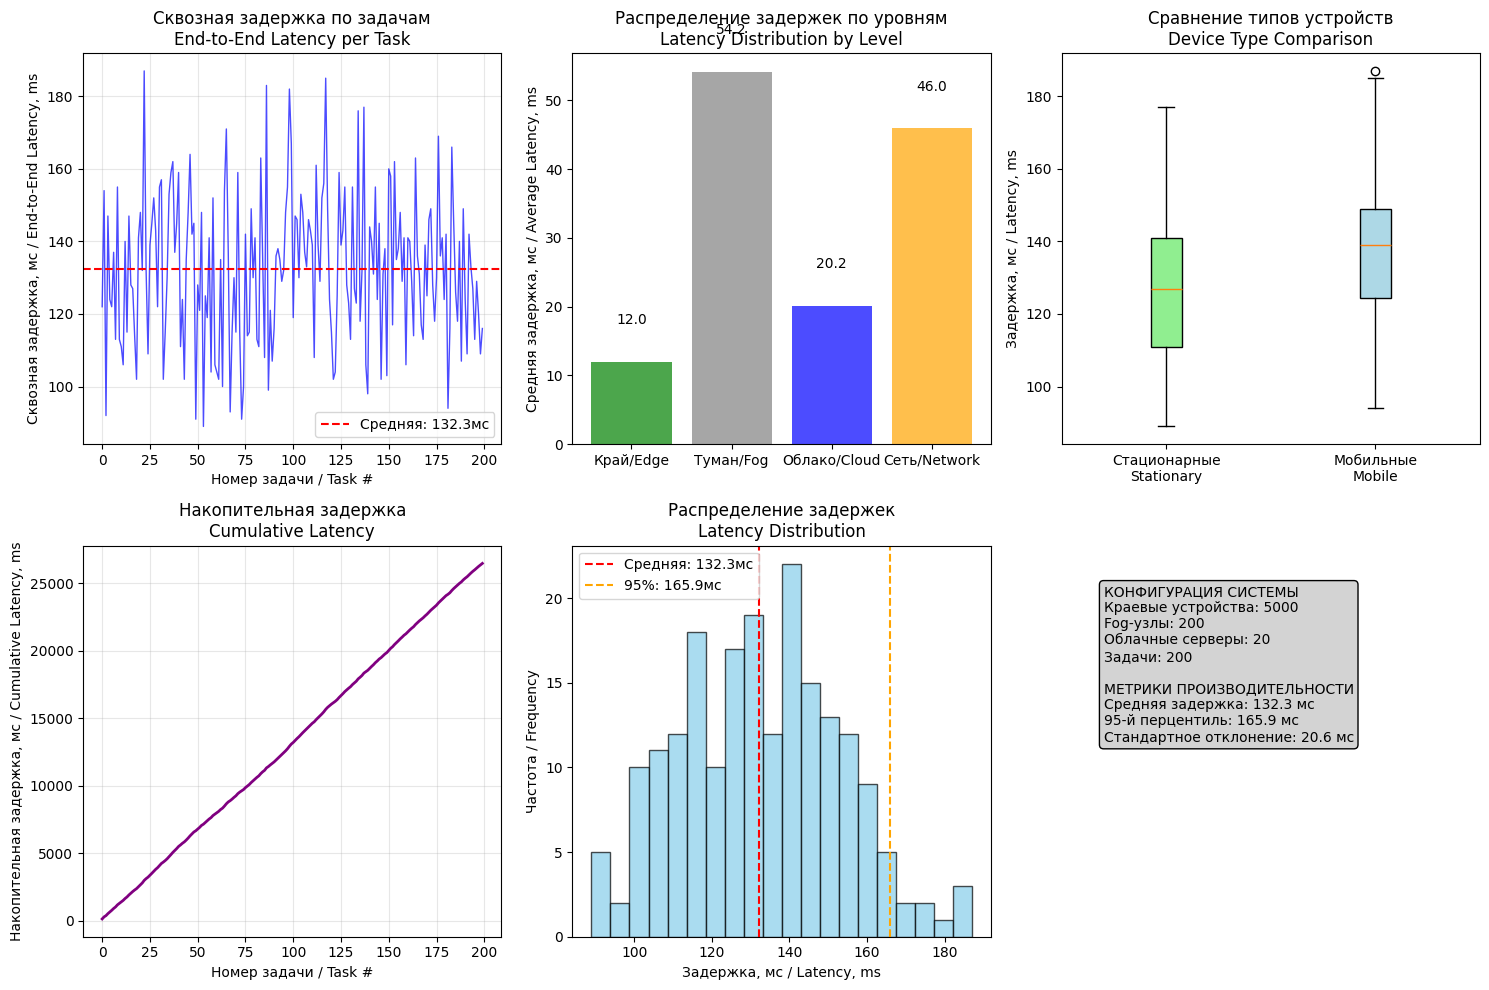


✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!
📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()


In [ ]:
"""
viz_cloud_fog_edge_pipeline_custom.py

Визуализация конвейера для эталонной архитектуры: Край → Туман → Облако
с возможностью настройки всех параметров системы

Показываем / We show:
  • Сквозная задержка "от краевого устройства до облака" для каждой задачи
  • Задержки на каждом уровне вычислений
  • Динамика очередей на Fog-узлах
  • Метрики производительности распределённой системы
"""
import random, statistics
import matplotlib.pyplot as plt
import numpy as np

class DistributedSystemSimulator:
    def __init__(self, n_edge_devices=100, n_fog_nodes=10, n_cloud_servers=3):
        self.n_edge_devices = n_edge_devices
        self.n_fog_nodes = n_fog_nodes
        self.n_cloud_servers = n_cloud_servers

        # Инициализация устройств
        self.edge_devices = self._init_edge_devices()
        self.fog_nodes = self._init_fog_nodes()
        self.cloud_servers = self._init_cloud_servers()

    def _init_edge_devices(self):
        """Инициализация краевых устройств (стационарные и мобильные)"""
        devices = []
        for i in range(self.n_edge_devices):
            device_type = "стационарный" if i % 2 == 0 else "мобильный"
            # Мобильные устройства имеют немного другие характеристики
            if device_type == "мобильный":
                processing_range = (8, 20)  # Немного выше задержка
                network_range = (8, 20)      # Менее стабильное соединение
            else:
                processing_range = (5, 15)  # Стабильная задержка
                network_range = (5, 15)      # Стабильное соединение

            devices.append({
                'id': f"Edge_{i}",
                'type': device_type,
                'processing_delay': random.randint(*processing_range),  # мс
                'network_delay': random.randint(*network_range),        # мс
                'assigned_fog': random.randint(0, self.n_fog_nodes-1)
            })
        return devices

    def _init_fog_nodes(self):
        """Инициализация Fog-узлов"""
        nodes = []
        for i in range(self.n_fog_nodes):
            # Разные Fog-узлы могут иметь разную производительность
            capacity_factor = random.uniform(0.8, 1.2)
            nodes.append({
                'id': f"Fog_{i}",
                'processing_delay_range': (int(30 * capacity_factor), int(80 * capacity_factor)),
                'queue_capacity': 200,
                'current_queue': 0,
                'assigned_cloud': random.randint(0, self.n_cloud_servers-1),
                'processed_tasks': 0
            })
        return nodes

    def _init_cloud_servers(self):
        """Инициализация облачных серверов"""
        servers = []
        for i in range(self.n_cloud_servers):
            # Облачные серверы обычно более производительные
            servers.append({
                'id': f"Cloud_{i}",
                'processing_delay_range': (10, 30),  # мс
                'storage_capacity': 1000,
                'processed_tasks': 0
            })
        return servers

def simulate_ethernet_architecture_custom(n_tasks=100, simulator=None, seed=42):
    """
    Симуляция эталонной архитектуры с кастомным симулятором
    """
    if simulator is None:
        simulator = DistributedSystemSimulator()

    random.seed(seed)
    tasks = []

    for task_id in range(n_tasks):
        # Случайное краевое устройство генерирует задачу
        edge_device = random.choice(simulator.edge_devices)
        fog_node = simulator.fog_nodes[edge_device['assigned_fog']]
        cloud_server = simulator.cloud_servers[fog_node['assigned_cloud']]

        # Задержки на каждом этапе
        edge_processing = edge_device['processing_delay']
        edge_to_fog_network = edge_device['network_delay']

        fog_processing = random.randint(*fog_node['processing_delay_range'])
        fog_queue_delay = fog_node['current_queue'] * 2  # 2 мс на задачу в очереди

        fog_to_cloud_network = random.randint(20, 50)  # Более высокая задержка до облака
        cloud_processing = random.randint(*cloud_server['processing_delay_range'])

        # Обновление очереди Fog-узла
        if fog_node['current_queue'] < fog_node['queue_capacity']:
            fog_node['current_queue'] += 1
        else:
            fog_queue_delay += 10  # Штраф за переполнение очереди

        # Общая сквозная задержка
        end_to_end_latency = (edge_processing + edge_to_fog_network +
                             fog_processing + fog_queue_delay +
                             fog_to_cloud_network + cloud_processing)

        tasks.append({
            'task_id': task_id,
            'edge_device': edge_device['id'],
            'edge_type': edge_device['type'],
            'fog_node': fog_node['id'],
            'cloud_server': cloud_server['id'],
            'edge_processing': edge_processing,
            'edge_to_fog_network': edge_to_fog_network,
            'fog_processing': fog_processing,
            'fog_queue_delay': fog_queue_delay,
            'fog_to_cloud_network': fog_to_cloud_network,
            'cloud_processing': cloud_processing,
            'end_to_end_latency': end_to_end_latency
        })

        # Уменьшение очереди Fog-узла (обработка задач)
        if random.random() < 0.3:  # 30% chance to process a task from queue
            if fog_node['current_queue'] > 0:
                fog_node['current_queue'] -= 1
                fog_node['processed_tasks'] += 1

        # Обновление статистики облачного сервера
        cloud_server['processed_tasks'] += 1

    return tasks

def analyze_performance(tasks):
    """Анализ производительности системы"""
    latencies = [task['end_to_end_latency'] for task in tasks]
    edge_latencies = [task['edge_processing'] for task in tasks]
    fog_latencies = [task['fog_processing'] + task['fog_queue_delay'] for task in tasks]
    cloud_latencies = [task['cloud_processing'] for task in tasks]
    network_latencies = [task['edge_to_fog_network'] + task['fog_to_cloud_network'] for task in tasks]

    # Статистика
    stats = {
        'avg_end_to_end': statistics.mean(latencies),
        'p95_end_to_end': statistics.quantiles(latencies, n=20)[18],
        'p99_end_to_end': statistics.quantiles(latencies, n=100)[98],
        'avg_edge': statistics.mean(edge_latencies),
        'avg_fog': statistics.mean(fog_latencies),
        'avg_cloud': statistics.mean(cloud_latencies),
        'avg_network': statistics.mean(network_latencies),
        'max_latency': max(latencies),
        'min_latency': min(latencies),
        'std_latency': statistics.stdev(latencies) if len(latencies) > 1 else 0
    }

    return stats

def plot_comprehensive_results(tasks, stats, config):
    """Построение комплексных графиков результатов"""

    plt.figure(figsize=(15, 10))

    # График 1: Сквозная задержка по задачам
    plt.subplot(2, 3, 1)
    task_ids = [task['task_id'] for task in tasks]
    latencies = [task['end_to_end_latency'] for task in tasks]
    plt.plot(task_ids, latencies, 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=stats['avg_end_to_end'], color='r', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Сквозная задержка, мс / End-to-End Latency, ms')
    plt.title('Сквозная задержка по задачам\nEnd-to-End Latency per Task')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 2: Распределение задержек по уровням
    plt.subplot(2, 3, 2)
    components = ['Край/Edge', 'Туман/Fog', 'Облако/Cloud', 'Сеть/Network']
    avg_latencies = [stats['avg_edge'], stats['avg_fog'], stats['avg_cloud'], stats['avg_network']]
    colors = ['green', 'gray', 'blue', 'orange']
    bars = plt.bar(components, avg_latencies, color=colors, alpha=0.7)
    plt.ylabel('Средняя задержка, мс / Average Latency, ms')
    plt.title('Распределение задержек по уровням\nLatency Distribution by Level')

    # Добавление значений на столбцы
    for bar, value in zip(bars, avg_latencies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom')

    # График 3: Сравнение стационарных и мобильных устройств
    plt.subplot(2, 3, 3)
    stationary_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'стационарный']
    mobile_latencies = [task['end_to_end_latency'] for task in tasks if task['edge_type'] == 'мобильный']

    box_data = [stationary_latencies, mobile_latencies]
    box_labels = ['Стационарные\nStationary', 'Мобильные\nMobile']
    box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

    # Цвета для boxplot
    colors = ['lightgreen', 'lightblue']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel('Задержка, мс / Latency, ms')
    plt.title('Сравнение типов устройств\nDevice Type Comparison')

    # График 4: Накопительная задержка
    plt.subplot(2, 3, 4)
    cumulative_latency = np.cumsum([task['end_to_end_latency'] for task in tasks])
    plt.plot(task_ids, cumulative_latency, 'purple', linewidth=2)
    plt.xlabel('Номер задачи / Task #')
    plt.ylabel('Накопительная задержка, мс / Cumulative Latency, ms')
    plt.title('Накопительная задержка\nCumulative Latency')
    plt.grid(True, alpha=0.3)

    # График 5: Гистограмма распределения задержек
    plt.subplot(2, 3, 5)
    plt.hist(latencies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(stats['avg_end_to_end'], color='red', linestyle='--', label=f'Средняя: {stats["avg_end_to_end"]:.1f}мс')
    plt.axvline(stats['p95_end_to_end'], color='orange', linestyle='--', label=f'95%: {stats["p95_end_to_end"]:.1f}мс')
    plt.xlabel('Задержка, мс / Latency, ms')
    plt.ylabel('Частота / Frequency')
    plt.title('Распределение задержек\nLatency Distribution')
    plt.legend()

    # График 6: Информация о конфигурации
    plt.subplot(2, 3, 6)
    plt.axis('off')
    config_text = (
        f"КОНФИГУРАЦИЯ СИСТЕМЫ\n"
        f"Краевые устройства: {config['edge_devices']}\n"
        f"Fog-узлы: {config['fog_nodes']}\n"
        f"Облачные серверы: {config['cloud_servers']}\n"
        f"Задачи: {config['tasks']}\n\n"
        f"МЕТРИКИ ПРОИЗВОДИТЕЛЬНОСТИ\n"
        f"Средняя задержка: {stats['avg_end_to_end']:.1f} мс\n"
        f"95-й перцентиль: {stats['p95_end_to_end']:.1f} мс\n"
        f"Стандартное отклонение: {stats['std_latency']:.1f} мс"
    )
    plt.text(0.1, 0.9, config_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

def print_detailed_metrics(tasks, stats, config):
    """Вывод детализированных метрик"""
    print("=" * 70)
    print("МЕТРИКИ ЭТАЛОННОЙ АРХИТЕКТУРЫ / REFERENCE ARCHITECTURE METRICS")
    print("=" * 70)

    print(f"\nКОНФИГУРАЦИЯ СИСТЕМЫ / SYSTEM CONFIGURATION:")
    print(f"  Краевые устройства: {config['edge_devices']}")
    print(f"  Fog-узлы: {config['fog_nodes']}")
    print(f"  Облачные серверы: {config['cloud_servers']}")
    print(f"  Всего задач: {config['tasks']}")

    print(f"\nОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ / OVERALL PERFORMANCE:")
    print(f"  Средняя сквозная задержка: {stats['avg_end_to_end']:.2f} мс")
    print(f"  95-й перцентиль задержки: {stats['p95_end_to_end']:.2f} мс")
    print(f"  99-й перцентиль задержки: {stats['p99_end_to_end']:.2f} мс")
    print(f"  Стандартное отклонение: {stats['std_latency']:.2f} мс")
    print(f"  Минимальная задержка: {stats['min_latency']:.2f} мс")
    print(f"  Максимальная задержка: {stats['max_latency']:.2f} мс")

    print(f"\nРАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК / LATENCY DISTRIBUTION:")
    print(f"  Краевой уровень (Edge): {stats['avg_edge']:.2f} мс ({stats['avg_edge']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Туманный уровень (Fog): {stats['avg_fog']:.2f} мс ({stats['avg_fog']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Облачный уровень (Cloud): {stats['avg_cloud']:.2f} мс ({stats['avg_cloud']/stats['avg_end_to_end']*100:.1f}%)")
    print(f"  Сетевые задержки: {stats['avg_network']:.2f} мс ({stats['avg_network']/stats['avg_end_to_end']*100:.1f}%)")

    # Анализ по типам устройств
    stationary_tasks = [t for t in tasks if t['edge_type'] == 'стационарный']
    mobile_tasks = [t for t in tasks if t['edge_type'] == 'мобильный']

    if stationary_tasks:
        avg_stationary = statistics.mean([t['end_to_end_latency'] for t in stationary_tasks])
        print(f"\nСТАЦИОНАРНЫЕ УСТРОЙСТВА / STATIONARY DEVICES:")
        print(f"  Количество задач: {len(stationary_tasks)} ({len(stationary_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_stationary:.2f} мс")

    if mobile_tasks:
        avg_mobile = statistics.mean([t['end_to_end_latency'] for t in mobile_tasks])
        print(f"\nМОБИЛЬНЫЕ УСТРОЙСТВА / MOBILE DEVICES:")
        print(f"  Количество задач: {len(mobile_tasks)} ({len(mobile_tasks)/len(tasks)*100:.1f}%)")
        print(f"  Средняя задержка: {avg_mobile:.2f} мс")

def simulate_custom_config():
    """Функция для быстрой настройки конфигурации системы"""

    # 🎛️ НАСТРОЙКА ПАРАМЕТРОВ СИСТЕМЫ - МЕНЯЙТЕ ЭТИ ЧИСЛА 🎛️
    CONFIG = {
        'edge_devices': 5000,      # ↦ Количество краевых устройств (100-10000)
        'fog_nodes': 200,          # ↦ Количество Fog-узлов (100-10000)
        'cloud_servers': 20,       # ↦ Количество облачных серверов (1-100)
        'tasks': 200,             # ↦ Количество задач для симуляции
        'seed': 42               # ↦ Seed для воспроизводимости результатов
    }

    print(f"⚙️  Загружена конфигурация:")
    print(f"   Краевые устройства: {CONFIG['edge_devices']}")
    print(f"   Fog-узлы: {CONFIG['fog_nodes']}")
    print(f"   Облачные серверы: {CONFIG['cloud_servers']}")
    print(f"   Задачи: {CONFIG['tasks']}")

    # Проверка корректности конфигурации
    if CONFIG['edge_devices'] < CONFIG['fog_nodes']:
        print("⚠️  Предупреждение: Fog-узлов больше чем краевых устройств")

    if CONFIG['fog_nodes'] < CONFIG['cloud_servers']:
        print("⚠️  Предупреждение: Облачных серверов больше чем Fog-узлов")

    # Инициализация симулятора
    simulator = DistributedSystemSimulator(
        n_edge_devices=CONFIG['edge_devices'],
        n_fog_nodes=CONFIG['fog_nodes'],
        n_cloud_servers=CONFIG['cloud_servers']
    )

    # Запуск симуляции
    tasks = simulate_ethernet_architecture_custom(
        n_tasks=CONFIG['tasks'],
        simulator=simulator,
        seed=CONFIG['seed']
    )

    return tasks, simulator, CONFIG

def main():
    """Основная функция с настраиваемыми параметрами"""

    print("🚀 СИМУЛЯЦИЯ ЭТАЛОННОЙ АРХИТЕКТУРЫ: КРАЙ → ТУМАН → ОБЛАКО")
    print("🚀 REFERENCE ARCHITECTURE SIMULATION: EDGE → FOG → CLOUD")
    print("-" * 70)

    # Запуск симуляции с кастомной конфигурацией
    tasks, simulator, config = simulate_custom_config()

    # Анализ производительности
    stats = analyze_performance(tasks)

    # Вывод результатов
    print_detailed_metrics(tasks, stats, config)

    # Построение графиков
    plot_comprehensive_results(tasks, stats, config)

    print(f"\n✅ СИМУЛЯЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
    print(f"📊 Для изменения конфигурации отредактируйте словарь CONFIG в функции simulate_custom_config()")

if __name__ == '__main__':
    main()